# Jump-SABR Calibration Notebook

Full calibration pipeline: data loading, SABR, sequential Jump-SABR, joint Jump-SABR, Merton, benchmark models, and all thesis plots.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

from src.sabr import calibrate_sabr, hagan_vol
from src.merton import calibrate_merton, merton_implied_vol
from src.jump_sabr import calibrate_jump_sabr, calibrate_jump_sabr_joint, jump_sabr_implied_vol
from src.data_loader import get_smile_slice, list_available_smiles

print("All imports successful")

All imports successful


In [28]:
# Load the daily smile dataset
df = pd.read_csv('../data/btc_daily_smile.csv')
df['expiry'] = pd.to_datetime(df['expiry'])
df['date']   = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

print(f"Total observations:  {len(df):,}")
print(f"Date range:          {df['date'].min()} to {df['date'].max()}")
print(f"Unique dates:        {df['date'].nunique()}")
print(f"Unique expiries:     {df['expiry'].nunique()}")
print(f"Strike range:        ${df['strike'].min():,.0f} to ${df['strike'].max():,.0f}")
print(f"IV range:            {df['mark_iv'].min():.1%} to {df['mark_iv'].max():.1%}")
print()
print(df.head())

Total observations:  73,819
Date range:          2024-01-01 to 2026-03-15
Unique dates:        805
Unique expiries:     120
Strike range:        $30,000 to $160,000
IV range:            11.2% to 142.6%

         date     expiry   strike option_type  iv_median   iv_mean   mark_iv  \
0  2024-01-01 2024-01-12  42000.0           C     0.6903  0.687629  0.690542   
1  2024-01-01 2024-01-12  43000.0           C     0.6694  0.673748  0.674446   
2  2024-01-01 2024-01-12  44000.0           C     0.6925  0.693876  0.703470   
3  2024-01-01 2024-01-12  45000.0           C     0.6851  0.690358  0.687932   
4  2024-01-01 2024-01-12  46000.0           C     0.6855  0.692581  0.692162   

   n_trades  total_volume  index_price         T  moneyness currency  
0        14          11.4     43478.93  0.030116   0.965985      BTC  
1        42          11.1     43474.48  0.030116   0.989086      BTC  
2        37         131.0     43508.66  0.030116   1.011293      BTC  
3        26          17.2     43

In [29]:
# List available smiles with enough strikes for calibration
available = list_available_smiles(df, min_strikes=6)
print(f"Smiles available for calibration: {len(available):,}")
print(f"Unique dates with smiles: {available['date'].nunique()}")
print()
print("First 20 available smiles:")
print(available.head(20).to_string())
print()

# Maturity distribution
available['T_days'] = (pd.to_datetime(available['expiry']) - 
                        pd.to_datetime(available['date'])).dt.days
print("Maturity distribution (days):")
print(available['T_days'].describe().round(1))


Smiles available for calibration: 4,339
Unique dates with smiles: 805

First 20 available smiles:
          date     expiry  n_strikes
0   2024-01-01 2024-01-12         12
1   2024-01-01 2024-01-19          9
2   2024-01-01 2024-01-26         14
3   2024-01-01 2024-02-23         12
4   2024-01-01 2024-03-29         13
5   2024-01-01 2024-06-28         10
6   2024-01-02 2024-01-12         19
7   2024-01-02 2024-01-19         11
8   2024-01-02 2024-01-26         17
9   2024-01-02 2024-02-23         17
10  2024-01-02 2024-03-29         16
11  2024-01-02 2024-06-28         14
12  2024-01-03 2024-01-12         21
13  2024-01-03 2024-01-19         13
14  2024-01-03 2024-01-26         21
15  2024-01-03 2024-02-23         15
16  2024-01-03 2024-03-29         19
17  2024-01-03 2024-06-28         14
18  2024-01-04 2024-01-12         20
19  2024-01-04 2024-01-19         12

Maturity distribution (days):
count    4339.0
mean       50.2
std        43.0
min         7.0
25%        16.0
50%        35.

In [7]:
import time

# Strategy: 
# - Calibrate SABR + Jump-SABR on ALL 4339 smiles (fast)
# - Calibrate Merton on weekly sample only (slow but manageable)

results = []
errors  = []
total   = len(available)
start   = time.time()

for idx, (i, row) in enumerate(available.iterrows()):
    date   = str(row['date'])[:10]
    expiry = row['expiry']

    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        if len(strikes) < 6:
            continue

        # SABR
        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)

        # Jump-SABR
        js_params, js_rmse = calibrate_jump_sabr(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        # Merton — only on Fridays (weekly sample)
        merton_rmse   = np.nan
        merton_params = {'sigma': np.nan, 'lam': np.nan,
                         'mu_J': np.nan, 'delta': np.nan}

        if pd.to_datetime(date).weekday() == 4:  # Friday
            try:
                merton_params, merton_rmse = calibrate_merton(
                    F, T, strikes, vols, n_terms=15)
            except Exception:
                pass

        results.append({
            'date':          date,
            'expiry':        str(expiry)[:10],
            'T':             round(T, 4),
            'F':             round(F, 2),
            'n_strikes':     len(strikes),
            'sabr_alpha':    round(sabr_params['alpha'], 4),
            'sabr_rho':      round(sabr_params['rho'],   4),
            'sabr_nu':       round(sabr_params['nu'],    4),
            'sabr_rmse':     round(sabr_rmse,            6),
            'merton_sigma':  round(merton_params['sigma'], 4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_lam':    round(merton_params['lam'],   4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_muJ':    round(merton_params['mu_J'],  4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_delta':  round(merton_params['delta'], 4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_rmse':   round(merton_rmse, 6)
                             if not np.isnan(merton_rmse) else np.nan,
            'js_alpha':      round(js_params['alpha'], 4),
            'js_rho':        round(js_params['rho'],   4),
            'js_nu':         round(js_params['nu'],    4),
            'js_lam':        round(js_params['lam'],   4),
            'js_muJ':        round(js_params['mu_J'],  4),
            'js_delta':      round(js_params['delta'], 4),
            'js_rmse':       round(js_rmse,            6),
        })

    except Exception as e:
        errors.append({
            'date': date, 'expiry': str(expiry)[:10], 'error': str(e)})
        continue

    if len(results) % 200 == 0 and len(results) > 0:
        elapsed = time.time() - start
        rate    = len(results) / elapsed
        eta     = (total - len(results)) / rate / 60
        print(f"  {len(results):4d}/{total} | "
              f"SABR: {np.mean([r['sabr_rmse'] for r in results]):.4f} | "
              f"JS: {np.mean([r['js_rmse'] for r in results]):.4f} | "
              f"ETA: {eta:.0f} min")

df_results = pd.DataFrame(results)
df_results.to_csv('../data/calibration_results.csv', index=False)
elapsed_total = (time.time() - start) / 60
print(f"\nDone: {len(df_results)} smiles in {elapsed_total:.1f} min")
print(df_results[['date','T','sabr_rmse','merton_rmse',
                  'js_rmse']].head(10).to_string())


   200/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 73 min
   400/4339 | SABR: 0.0095 | JS: 0.0095 | ETA: 83 min
   600/4339 | SABR: 0.0094 | JS: 0.0094 | ETA: 80 min
   800/4339 | SABR: 0.0089 | JS: 0.0088 | ETA: 75 min
  1000/4339 | SABR: 0.0084 | JS: 0.0084 | ETA: 70 min
  1200/4339 | SABR: 0.0084 | JS: 0.0084 | ETA: 66 min
  1400/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 60 min
  1600/4339 | SABR: 0.0078 | JS: 0.0078 | ETA: 56 min
  1800/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 53 min
  2000/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 49 min
  2200/4339 | SABR: 0.0079 | JS: 0.0079 | ETA: 46 min
  2400/4339 | SABR: 0.0079 | JS: 0.0079 | ETA: 42 min
  2600/4339 | SABR: 0.0078 | JS: 0.0078 | ETA: 38 min
  2800/4339 | SABR: 0.0077 | JS: 0.0077 | ETA: 33 min
  3000/4339 | SABR: 0.0076 | JS: 0.0076 | ETA: 29 min
  3200/4339 | SABR: 0.0075 | JS: 0.0075 | ETA: 25 min
  3400/4339 | SABR: 0.0074 | JS: 0.0074 | ETA: 21 min
  3600/4339 | SABR: 0.0075 | JS: 0.0075 | ETA: 17 min
  3800/4339 | SABR: 0.0076 |

In [30]:
# Joint calibration — import from src (canonical implementation)
from src.jump_sabr import calibrate_jump_sabr_joint

print("Joint calibrator imported from src.jump_sabr.calibrate_jump_sabr_joint")

In [60]:
# Weekly sample joint calibration — all maturities, full period
import time

# Take one smile per week — every Friday, all maturities 7-180 days
weekly = available[pd.to_datetime(available['date']).dt.weekday == 4].copy()
weekly = weekly[
    (weekly['expiry'] - pd.to_datetime(weekly['date'])).dt.days.between(7, 180)
].sort_values('date')

print(f"Full weekly sample all maturities: {len(weekly)} smiles")
print(f"Date range: {weekly['date'].min()} to {weekly['date'].max()}")

joint_results = []
n_nan         = 0
start         = time.time()

for idx, (i, row) in enumerate(weekly.iterrows()):
    date   = str(row['date'])[:10]
    expiry = row['expiry']
    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        if len(strikes) < 6:
            continue

        # Sequential SABR
        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)

        # Joint Jump-SABR
        js_params, js_rmse = calibrate_jump_sabr_joint(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        # Skip if JS returned NaN
        if np.isnan(js_rmse):
            n_nan += 1
            continue

        joint_results.append({
            'date':        date,
            'expiry':      str(expiry)[:10],
            'T':           round(T, 4),
            'F':           round(F, 2),
            'sabr_rmse':   round(sabr_rmse, 6),
            'js_rmse':     round(js_rmse,   6),
            'js_alpha':    round(js_params['alpha'], 4),
            'js_rho':      round(js_params['rho'],   4),
            'js_nu':       round(js_params['nu'],    4),
            'js_lam':      round(js_params['lam'],   4),
            'js_muJ':      round(js_params['mu_J'],  4),
            'js_delta':    round(js_params['delta'], 4),
            'improvement': round((sabr_rmse - js_rmse) / sabr_rmse * 100, 2)
        })

    except Exception as e:
        n_nan += 1
        continue

    if (idx + 1) % 20 == 0:
        elapsed  = time.time() - start
        eta      = (len(weekly) - idx - 1) / (idx + 1) * elapsed / 60
        valid    = [r for r in joint_results if not np.isnan(r['js_rmse'])]
        if valid:
            mean_imp  = np.mean([r['improvement'] for r in valid])
            mean_sabr = np.mean([r['sabr_rmse']   for r in valid])
            mean_js   = np.mean([r['js_rmse']     for r in valid])
            print(f"  {idx+1:3d}/{len(weekly)} | "
                  f"SABR: {mean_sabr:.4f} | "
                  f"JS joint: {mean_js:.4f} | "
                  f"Improvement: {mean_imp:.1f}% | "
                  f"Failed: {n_nan} | "
                  f"ETA: {eta:.0f} min")

df_joint_full = pd.DataFrame(joint_results)
df_joint_full.to_csv('../data/joint_calibration_full.csv', index=False)

elapsed_total = (time.time() - start) / 60
print(f"\nJoint calibration done: {len(df_joint_full)} smiles "
      f"({n_nan} failed, "
      f"{n_nan/(len(df_joint_full)+n_nan)*100:.1f}% failure rate)")
print(f"\nSABR mean RMSE:       {df_joint_full['sabr_rmse'].mean():.6f}")
print(f"Jump-SABR mean RMSE:  {df_joint_full['js_rmse'].mean():.6f}")
print(f"Mean improvement:     {df_joint_full['improvement'].mean():.2f}%")
print(f"Total runtime:        {elapsed_total:.1f} min")
print(f"\nLambda distribution:")
print(df_joint_full['js_lam'].describe().round(3))

Full weekly sample all maturities: 718 smiles
Date range: 2024-01-05 to 2026-03-13
   20/718 | SABR: 0.0082 | JS joint: 0.0069 | Improvement: 4.5% | Failed: 0 | ETA: 122 min
   40/718 | SABR: 0.0084 | JS joint: 0.0072 | Improvement: 7.4% | Failed: 0 | ETA: 111 min
   60/718 | SABR: 0.0087 | JS joint: 0.0077 | Improvement: 6.6% | Failed: 0 | ETA: 108 min
   80/718 | SABR: 0.0094 | JS joint: 0.0085 | Improvement: 5.0% | Failed: 3 | ETA: 114 min
  100/718 | SABR: 0.0092 | JS joint: 0.0083 | Improvement: 5.4% | Failed: 3 | ETA: 118 min
  120/718 | SABR: 0.0088 | JS joint: 0.0081 | Improvement: 5.1% | Failed: 3 | ETA: 113 min
  140/718 | SABR: 0.0086 | JS joint: 0.0079 | Improvement: 5.1% | Failed: 3 | ETA: 109 min
  160/718 | SABR: 0.0087 | JS joint: 0.0080 | Improvement: 4.1% | Failed: 4 | ETA: 105 min
  180/718 | SABR: 0.0085 | JS joint: 0.0078 | Improvement: 3.9% | Failed: 4 | ETA: 98 min
  200/718 | SABR: 0.0084 | JS joint: 0.0078 | Improvement: 4.4% | Failed: 4 | ETA: 95 min
  220/718

In [11]:
from scipy import stats

df_joint_full = pd.read_csv('../data/joint_calibration_full.csv')
df_joint_full = df_joint_full.dropna(subset=['js_rmse', 'sabr_rmse'])

t_stat, p_val = stats.ttest_rel(df_joint_full['sabr_rmse'],
                                 df_joint_full['js_rmse'])
w_stat, w_pval = stats.wilcoxon(df_joint_full['sabr_rmse'],
                                 df_joint_full['js_rmse'])

print(f"Sample size: {len(df_joint_full)}")
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_val:.6f}")
print(f"  Significant at 1%: {p_val < 0.01}")
print(f"\nWilcoxon signed-rank test:")
print(f"  p-value:     {w_pval:.6f}")
print(f"  Significant at 1%: {w_pval < 0.01}")
print(f"\nMean SABR RMSE:   {df_joint_full['sabr_rmse'].mean():.6f}")
print(f"Mean JS RMSE:     {df_joint_full['js_rmse'].mean():.6f}")
print(f"Mean improvement: {df_joint_full['improvement'].mean():.2f}%")

Sample size: 697

Paired t-test:
  t-statistic: 6.822
  p-value:     0.000000
  Significant at 1%: True

Wilcoxon signed-rank test:
  p-value:     0.000000
  Significant at 1%: True

Mean SABR RMSE:   0.008909
Mean JS RMSE:     0.008072
Mean improvement: 5.16%


In [12]:
df_joint_full['improvement_winsorised'] = df_joint_full['improvement'].clip(upper=50)
print(f"Raw mean improvement:        {df_joint_full['improvement'].mean():.2f}%")
print(f"Winsorised mean improvement: {df_joint_full['improvement_winsorised'].mean():.2f}%")
print(f"Smiles with improvement > 50%: {(df_joint_full['improvement'] > 50).sum()}")
df_joint_full.to_csv('../data/joint_calibration_full.csv', index=False)
print("Saved updated file")

Raw mean improvement:        5.16%
Winsorised mean improvement: 4.73%
Smiles with improvement > 50%: 24
Saved updated file


In [13]:
from scipy import stats

df_joint_full = pd.read_csv('../data/joint_calibration_full.csv')
df_joint_full = df_joint_full.dropna(subset=['js_rmse', 'sabr_rmse'])
df_joint_full['T_bucket'] = pd.cut(
    df_joint_full['T'] * 365,
    bins=[0, 30, 90, 180],
    labels=['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']
)

print("=== SIGNIFICANCE BY MATURITY BUCKET ===\n")
for bucket in ['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']:
    sub = df_joint_full[df_joint_full['T_bucket'] == bucket]
    t, p = stats.ttest_rel(sub['sabr_rmse'], sub['js_rmse'])
    w, wp = stats.wilcoxon(sub['sabr_rmse'], sub['js_rmse'])
    print(f"{bucket}")
    print(f"  n={len(sub)}, improvement={sub['improvement'].mean():.2f}%")
    print(f"  t={t:.3f}, p={p:.6f}, significant={p<0.01}")
    print(f"  Wilcoxon p={wp:.6f}, significant={wp<0.01}")
    print()

=== SIGNIFICANCE BY MATURITY BUCKET ===

Short (<30d)
  n=351, improvement=6.16%
  t=6.068, p=0.000000, significant=True
  Wilcoxon p=0.000000, significant=True

Medium (30-90d)
  n=219, improvement=3.18%
  t=3.321, p=0.001050, significant=True
  Wilcoxon p=0.000141, significant=True

Long (90-180d)
  n=127, improvement=5.80%
  t=3.640, p=0.000396, significant=True
  Wilcoxon p=0.003001, significant=True



In [14]:
# ─────────────────────────────────────────────
# Benchmark models
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import os

BENCH_CSV = '../data/benchmark_results.csv'

# Always define bsm_rmse at top level so downstream cells can use it
def bsm_rmse(strikes, vols, F):
    atm_idx = np.argmin(np.abs(np.array(strikes) - F))
    atm_vol = vols[atm_idx]
    return np.sqrt(np.mean((atm_vol - np.array(vols))**2))

if os.path.exists(BENCH_CSV):
    df_bench = pd.read_csv(BENCH_CSV)
    keep = [c for c in df_bench.columns if c not in ['sticky_strike_rmse','sticky_delta_rmse']]
    df_bench = df_bench[keep]
    print('Loaded from disk:', len(df_bench), 'smiles')
    print('Mean BSM RMSE:', round(df_bench["bsm_rmse"].mean(), 6))
else:
    benchmark_results = []
    for i, row in available.iterrows():
        date   = str(row['date'])[:10]
        expiry = row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6:
                continue
            benchmark_results.append({
                'date':      date,
                'expiry':    str(expiry)[:10],
                'T':         round(T, 4),
                'F':         round(F, 2),
                'n_strikes': len(strikes),
                'bsm_rmse':  round(bsm_rmse(strikes, vols, F), 6),
            })
        except Exception:
            continue

    df_bench = pd.DataFrame(benchmark_results)
    df_bench.to_csv(BENCH_CSV, index=False)
    print('BSM benchmark computed:', len(df_bench), 'smiles')
    print('Mean BSM RMSE:', round(df_bench["bsm_rmse"].mean(), 6))


Loaded from disk: 4339 smiles
Mean BSM RMSE: 0.033969


In [15]:
# Merge all results into one master table
df_seq    = pd.read_csv('../data/calibration_results.csv')
df_joint  = pd.read_csv('../data/joint_calibration_full.csv')
df_bench  = pd.read_csv('../data/benchmark_results.csv')
df_merton = pd.read_csv('../data/merton_weekly.csv')[['date','expiry','merton_rmse']].dropna()
df_heston = pd.read_csv('../data/heston_weekly.csv')[['date','expiry','heston_rmse']].dropna()
df_bates  = pd.read_csv('../data/bates_weekly.csv')[['date','expiry','bates_rmse']].dropna()

df_joint = df_joint.dropna(subset=['js_rmse'])

# Drop conflicting rmse columns from df_seq to avoid _x/_y clash on merge
drop_cols = [c for c in df_seq.columns if c in
             ['merton_rmse','bsm_rmse','sticky_strike_rmse','sticky_delta_rmse']]
df_seq = df_seq.drop(columns=drop_cols)

# Rename sequential js_rmse to js_seq_rmse to keep it distinct
df_seq = df_seq.rename(columns={'js_rmse': 'js_seq_rmse'})

# Merge sequential + BSM benchmark
df_master = df_seq.merge(
    df_bench[['date','expiry','T','bsm_rmse']],
    on=['date','expiry','T'], how='left')

# Add joint JS rmse
df_master = df_master.merge(
    df_joint[['date','expiry','js_rmse']].rename(columns={'js_rmse':'js_joint_rmse'}),
    on=['date','expiry'], how='left')

# Add Merton, Heston, Bates rmse
df_master = df_master.merge(df_merton, on=['date','expiry'], how='left')
df_master = df_master.merge(df_heston, on=['date','expiry'], how='left')
df_master = df_master.merge(df_bates,  on=['date','expiry'], how='left')

print(f'Master table: {len(df_master)} rows')
print('RMSE columns:', [c for c in df_master.columns if 'rmse' in c])

# Maturity buckets
df_master['T_bucket'] = pd.cut(df_master['T']*365, bins=[0,30,90,9999],
    labels=['Short (<30d)','Medium (30-90d)','Long (>90d)'])

# Restrict to smiles where joint JS has data
df_common = df_master.dropna(subset=['js_joint_rmse'])
print(f'Common subset: {len(df_common)} smiles')

final_summary = df_common.groupby('T_bucket', observed=True).agg(
    n_smiles = ('sabr_rmse',     'count'),
    bsm      = ('bsm_rmse',      'mean'),
    merton   = ('merton_rmse',   'mean'),
    heston   = ('heston_rmse',   'mean'),
    bates    = ('bates_rmse',    'mean'),
    sabr     = ('sabr_rmse',     'mean'),
    js_seq   = ('js_seq_rmse',   'mean'),
    js_joint = ('js_joint_rmse', 'mean'),
).round(6)

final_summary['improvement'] = (
    (final_summary['sabr'] - final_summary['js_joint'])
    / final_summary['sabr'] * 100
).round(2)

print('\n=== MAIN RESULTS TABLE ===')
print(final_summary.to_string())

df_master.to_csv('../data/master_results.csv', index=False)
print('\nSaved to data/master_results.csv')


Master table: 4339 rows
RMSE columns: ['sabr_rmse', 'js_seq_rmse', 'bsm_rmse', 'js_joint_rmse', 'merton_rmse']
Common subset: 697 smiles

=== MAIN RESULTS TABLE ===
                 n_smiles       bsm    merton      sabr    js_seq  js_joint  improvement
T_bucket                                                                                
Short (<30d)          351  0.056249  0.018616  0.012929  0.012838  0.011514        10.94
Medium (30-90d)       219  0.021355  0.010591  0.005771  0.005774  0.005491         4.85
Long (>90d)           127  0.013658  0.007229  0.003210  0.003220  0.003009         6.26

Saved to data/master_results.csv


In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# Plot settings — clean academic style
# ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'figure.dpi':        150,
})

print("Plot settings loaded")

Plot settings loaded


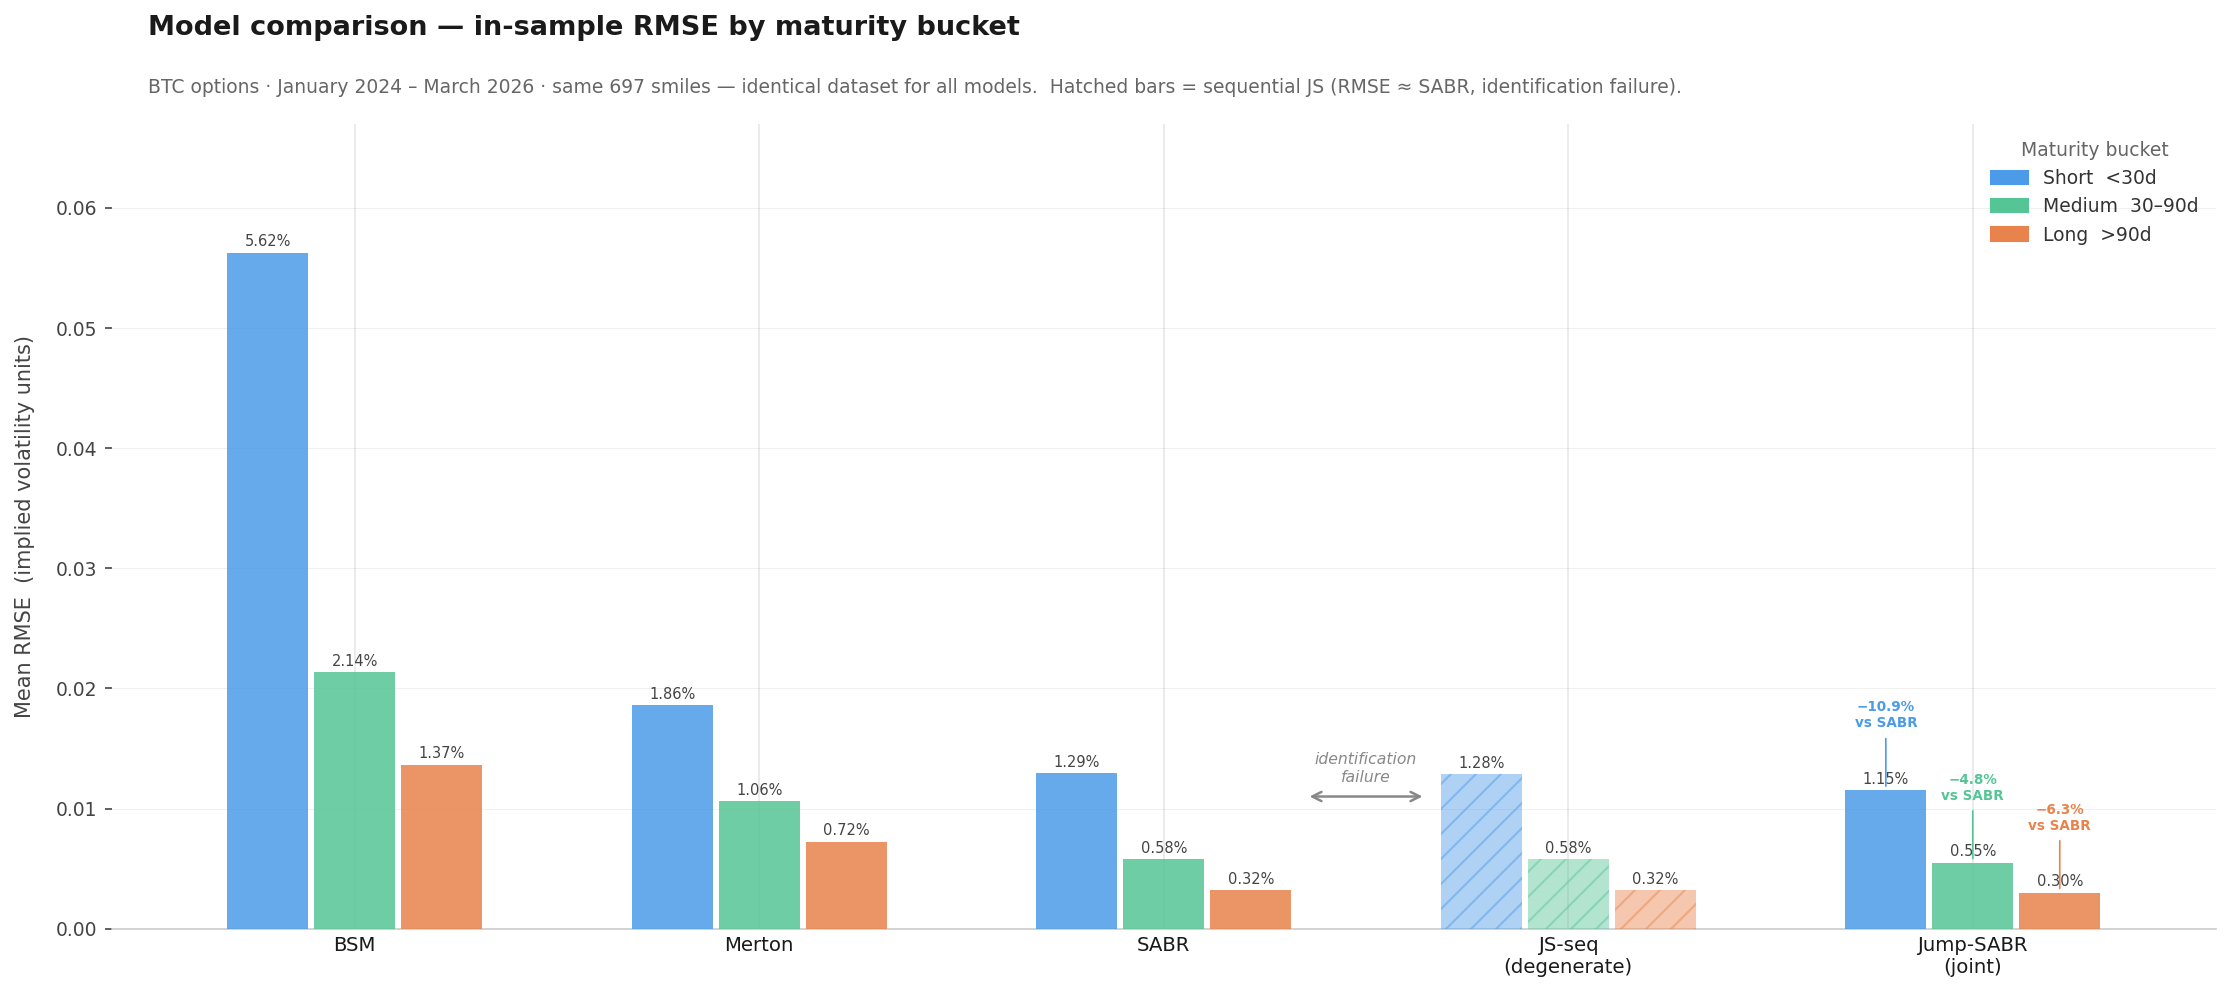

Plot 1 saved


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models       = ['BSM', 'Merton', 'Heston', 'Bates', 'SABR', 'JS-seq\n(degenerate)', 'Jump-SABR\n(joint)']
model_cols   = ['bsm', 'merton', 'heston', 'bates', 'sabr', 'js_seq', 'js_joint']
bucket_labels = ['Short  <30d', 'Medium  30\u201390d', 'Long  >90d']
bucket_colors = ['#4C9BE8', '#56C596', '#E8834C']
buckets       = ['Short (<30d)', 'Medium (30-90d)', 'Long (>90d)']

x = np.arange(len(models)); width = 0.20; gap = 0.015

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#ffffff'); ax.set_facecolor('#ffffff')

for bi, (bucket, color) in enumerate(zip(buckets, bucket_colors)):
    row    = final_summary.loc[bucket]
    vals   = [row[c] for c in model_cols]
    offset = (bi - 1) * (width + gap)
    for j, (val, model_col) in enumerate(zip(vals, model_cols)):
        hatch = '//' if model_col == 'js_seq' else None
        ax.bar(x[j] + offset, val, width,
               color=color,
               alpha=0.45 if model_col == 'js_seq' else 0.85,
               zorder=3, linewidth=0, hatch=hatch,
               edgecolor=color if hatch else 'none')
        if not np.isnan(val):
            ax.text(x[j] + offset, val + 0.0003,
                    f'{val*100:.2f}%', ha='center', va='bottom',
                    fontsize=7, color='#444444')

# Improvement annotations on Jump-SABR joint bars
for bi, (bucket, color) in enumerate(zip(buckets, bucket_colors)):
    row = final_summary.loc[bucket]; imp = row['improvement']
    offset = (bi - 1) * (width + gap)
    ax.annotate(f'\u2212{imp:.1f}%\nvs SABR',
                xy=(x[-1] + offset, row['js_joint']),
                xytext=(x[-1] + offset, row['js_joint'] + 0.005),
                fontsize=6.5, color=color, fontweight='bold', ha='center', va='bottom',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8))

# Annotation: JS-seq ≈ SABR (identification failure)
ax.annotate('', xy=(x[5] - 0.35, 0.011), xytext=(x[4] + 0.35, 0.011),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.2))
ax.text((x[4] + x[5]) / 2, 0.012, 'identification\nfailure',
        ha='center', va='bottom', fontsize=7.5, color='#888888', style='italic')

ax.yaxis.grid(True, color='#000000', alpha=0.06, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(x); ax.set_xticklabels(models, color='#1a1a1a', fontsize=9.5)
ax.set_ylabel('Mean RMSE  (implied volatility units)', color='#444444', fontsize=10, labelpad=10)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.tick_params(axis='x', length=0)
for spine in ax.spines.values(): spine.set_visible(False)
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('#cccccc')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(bucket_colors, bucket_labels)]
legend  = ax.legend(handles=patches, loc='upper right', framealpha=0,
                    labelcolor='#333333', fontsize=9, title='Maturity bucket', title_fontsize=9)
legend.get_title().set_color('#666666')

ax.set_ylim(0, 0.067); ax.set_xlim(-0.6, len(models) - 0.4)

fig.text(0.07, 0.96, 'Model comparison \u2014 in-sample RMSE by maturity bucket',
         color='#1a1a1a', fontsize=13, fontweight='bold', va='top')
fig.text(0.07, 0.90,
         f'BTC options \u00b7 January 2024 \u2013 March 2026 \u00b7 '
         f'same {int(final_summary["n_smiles"].sum())} smiles \u2014 identical dataset for all models.  '
         'Hatched bars = sequential JS (RMSE \u2248 SABR, identification failure).',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.savefig('../results/plot1_rmse_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 1 saved')


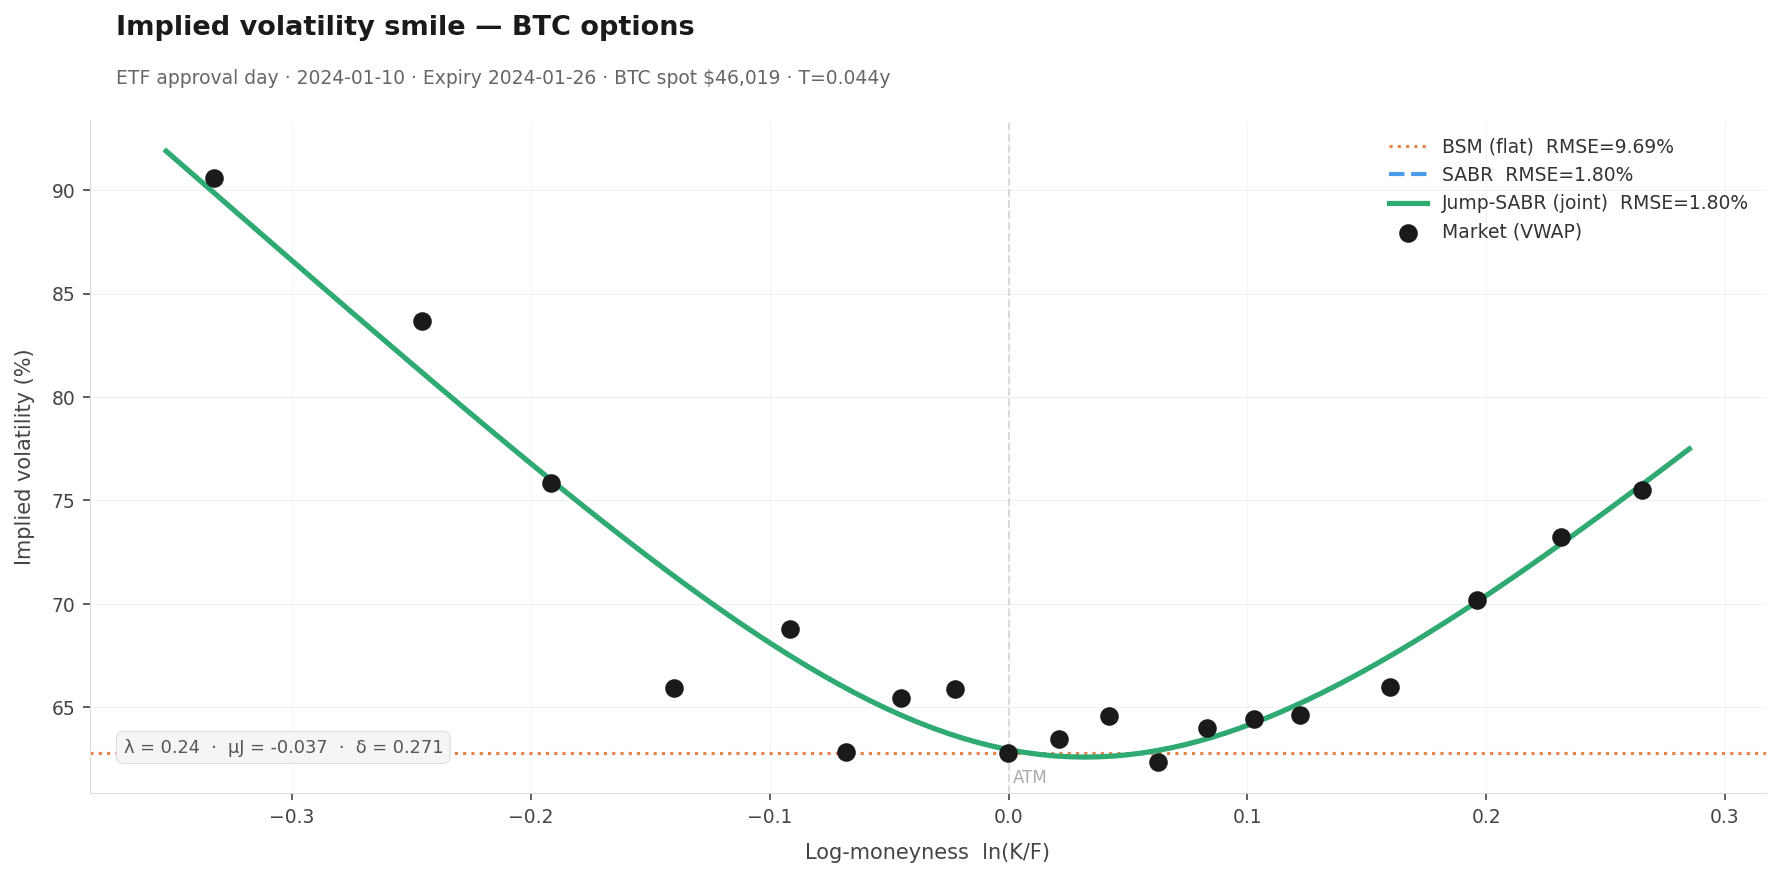

Jump params: λ=0.242, μJ=-0.037, δ=0.271
SABR RMSE: 0.017965 | JS RMSE: 0.017965


In [18]:
# ─────────────────────────────────────────────
# Plot 2 — Smile fit on ETF approval day (redesigned)
# ─────────────────────────────────────────────
target_date   = '2024-01-10'
target_expiry = pd.to_datetime('2024-01-26')

strikes, vols, F, T = get_smile_slice(
    df, target_date, target_expiry, iv_col='mark_iv')

sabr_params, sabr_rmse = calibrate_sabr(F, T, strikes, vols, beta=1.0)
js_params,   js_rmse   = calibrate_jump_sabr_joint(F, T, strikes, vols,
                                                    beta=1.0, n_terms=15)

k_range  = np.linspace(strikes[0]*0.98, strikes[-1]*1.02, 100)
lm_market = np.log(strikes / F)
lm_range  = np.log(k_range / F)

sabr_fit = [hagan_vol(F, K, T,
            sabr_params['alpha'], sabr_params['beta'],
            sabr_params['rho'],   sabr_params['nu'])
            for K in k_range]

js_fit = [jump_sabr_implied_vol(F, K, T, 0,
           js_params['alpha'], js_params['beta'],
           js_params['rho'],   js_params['nu'],
           js_params['lam'],   js_params['mu_J'],
           js_params['delta'], 15)
          for K in k_range]

atm_idx  = np.argmin(np.abs(strikes - F))
bsm_flat = vols[atm_idx]
bsm_rmse_val = bsm_rmse(strikes, vols, F)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Plot elements
ax.axhline(bsm_flat*100, color='#E8834C', linestyle=':',
           linewidth=1.5, label=f'BSM (flat)  RMSE={bsm_rmse_val*100:.2f}%',
           zorder=2)
ax.plot(lm_range, [v*100 for v in sabr_fit],
        color='#4C9BE8', linestyle='--', linewidth=2,
        label=f'SABR  RMSE={sabr_rmse*100:.2f}%', zorder=3)
ax.plot(lm_range, [v*100 for v in js_fit],
        color='#2eaa72', linewidth=2.5,
        label=f'Jump-SABR (joint)  RMSE={js_rmse*100:.2f}%', zorder=4)
ax.scatter(lm_market, [v*100 for v in vols],
           color='#1a1a1a', zorder=5, s=55,
           label='Market (VWAP)', linewidths=1.5)

# ATM line
ax.axvline(0, color='#cccccc', linestyle='--', alpha=0.7,
           linewidth=1, zorder=1)
ax.text(0.002, ax.get_ylim()[0] + 0.5, 'ATM',
        fontsize=8, color='#aaaaaa')

# Grid
ax.yaxis.grid(True, color='#000000', alpha=0.06,
              linewidth=0.5, zorder=0)
ax.xaxis.grid(True, color='#000000', alpha=0.04,
              linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Axes
ax.set_xlabel('Log-moneyness  ln(K/F)',
              color='#444444', fontsize=10, labelpad=8)
ax.set_ylabel('Implied volatility (%)',
              color='#444444', fontsize=10, labelpad=8)
ax.tick_params(colors='#444444', labelsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_color('#dddddd')
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Legend
ax.legend(loc='upper right', framealpha=0,
          labelcolor='#333333', fontsize=9)

# Jump params box
ax.text(0.02, 0.06,
        f'λ = {js_params["lam"]:.2f}  ·  '
        f'μJ = {js_params["mu_J"]:.3f}  ·  '
        f'δ = {js_params["delta"]:.3f}',
        transform=ax.transAxes, fontsize=8.5,
        color='#555555',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#f5f5f5',
                  edgecolor='#dddddd',
                  linewidth=0.5))

# Title
fig.text(0.07, 0.97,
         'Implied volatility smile — BTC options',
         color='#1a1a1a', fontsize=13,
         fontweight='bold', va='top')
fig.text(0.07, 0.91,
         f'ETF approval day · {target_date} · '
         f'Expiry {target_expiry.date()} · '
         f'BTC spot ${F:,.0f} · T={T:.3f}y',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../results/plot2_smile_ETF_day.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print(f"Jump params: λ={js_params['lam']:.3f}, "
      f"μJ={js_params['mu_J']:.3f}, δ={js_params['delta']:.3f}")
print(f"SABR RMSE: {sabr_rmse:.6f} | JS RMSE: {js_rmse:.6f}")

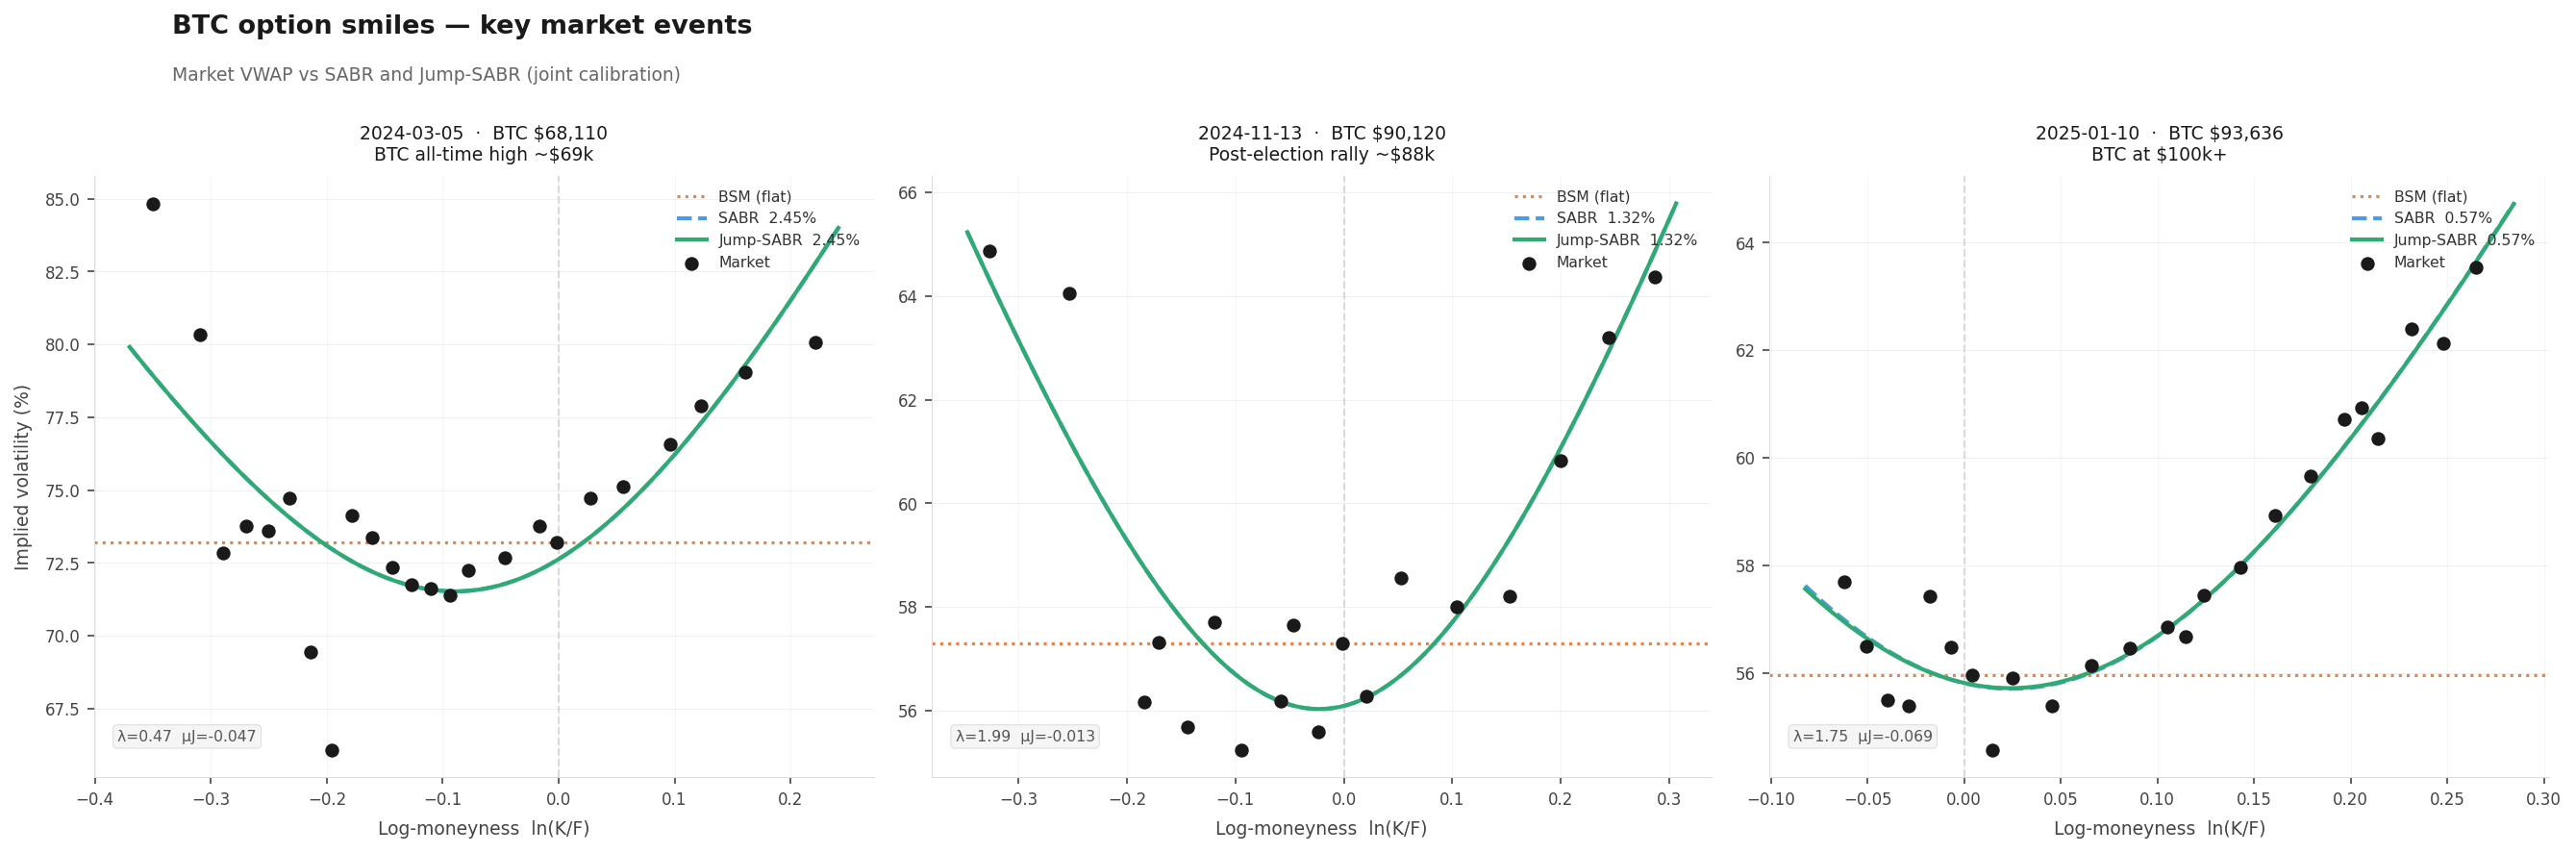

Plot 3 saved


In [56]:
# ─────────────────────────────────────────────
# Plot 3 — Multiple smile plots on key dates (redesigned)
# ─────────────────────────────────────────────
key_dates = [
    ('2024-03-05', pd.to_datetime('2024-03-29'), 'BTC all-time high ~$69k'),
    ('2024-11-13', pd.to_datetime('2024-12-27'), 'Post-election rally ~$88k'),
    ('2025-01-10', pd.to_datetime('2025-01-31'), 'BTC at $100k+'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')

for ax, (date, expiry, title) in zip(axes, key_dates):
    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)
        js_params, js_rmse = calibrate_jump_sabr_joint(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        k_range   = np.linspace(strikes[0]*0.98, strikes[-1]*1.02, 100)
        lm_market = np.log(strikes / F)
        lm_range  = np.log(k_range / F)

        sabr_fit = [hagan_vol(F, K, T,
                    sabr_params['alpha'], sabr_params['beta'],
                    sabr_params['rho'],   sabr_params['nu'])
                    for K in k_range]

        js_fit = [jump_sabr_implied_vol(F, K, T, 0,
                   js_params['alpha'], js_params['beta'],
                   js_params['rho'],   js_params['nu'],
                   js_params['lam'],   js_params['mu_J'],
                   js_params['delta'], 15)
                  for K in k_range]

        atm_idx  = np.argmin(np.abs(strikes - F))
        bsm_flat = vols[atm_idx]

        ax.set_facecolor('#ffffff')

        # Plot elements
        ax.axhline(bsm_flat*100, color='#E8834C', linestyle=':',
                   linewidth=1.5, label='BSM (flat)', zorder=2)
        ax.plot(lm_range, [v*100 for v in sabr_fit],
                color='#4C9BE8', linestyle='--', linewidth=2,
                label=f'SABR  {sabr_rmse*100:.2f}%', zorder=3)
        ax.plot(lm_range, [v*100 for v in js_fit],
                color='#2eaa72', linewidth=2,
                label=f'Jump-SABR  {js_rmse*100:.2f}%', zorder=4)
        ax.scatter(lm_market, [v*100 for v in vols],
                   color='#1a1a1a', zorder=5, s=35, label='Market')

        # ATM line
        ax.axvline(0, color='#cccccc', linestyle='--',
                   alpha=0.7, linewidth=1, zorder=1)

        # Grid
        ax.yaxis.grid(True, color='#000000', alpha=0.06,
                      linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, color='#000000', alpha=0.04,
                      linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        # Spines
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_color('#dddddd')
        ax.spines['left'].set_color('#dddddd')
        ax.spines['bottom'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)

        # Axes labels
        ax.set_xlabel('Log-moneyness  ln(K/F)',
                      color='#444444', fontsize=9, labelpad=6)
        if ax == axes[0]:
            ax.set_ylabel('Implied volatility (%)',
                          color='#444444', fontsize=9, labelpad=6)
        ax.tick_params(colors='#444444', labelsize=8)

        # Legend
        ax.legend(fontsize=7.5, framealpha=0,
                  labelcolor='#333333', loc='upper right')

        # Jump params annotation
        ax.text(0.03, 0.06,
                f'λ={js_params["lam"]:.2f}  μJ={js_params["mu_J"]:.3f}',
                transform=ax.transAxes, fontsize=7.5,
                color='#555555',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#f5f5f5',
                          edgecolor='#dddddd',
                          linewidth=0.5))

        # Panel title
        ax.set_title(f'{date}  ·  BTC ${F:,.0f}\n{title}',
                     fontsize=9, color='#1a1a1a', pad=8)

    except Exception as e:
        ax.set_title(f'{date}\nError: {str(e)[:50]}')
        print(f"Error on {date}: {e}")

fig.text(0.07, 0.98,
         'BTC option smiles — key market events',
         color='#1a1a1a', fontsize=13,
         fontweight='bold', va='top')
fig.text(0.07, 0.92,
         'Market VWAP vs SABR and Jump-SABR (joint calibration)',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../results/plot3_key_smiles.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print("Plot 3 saved")

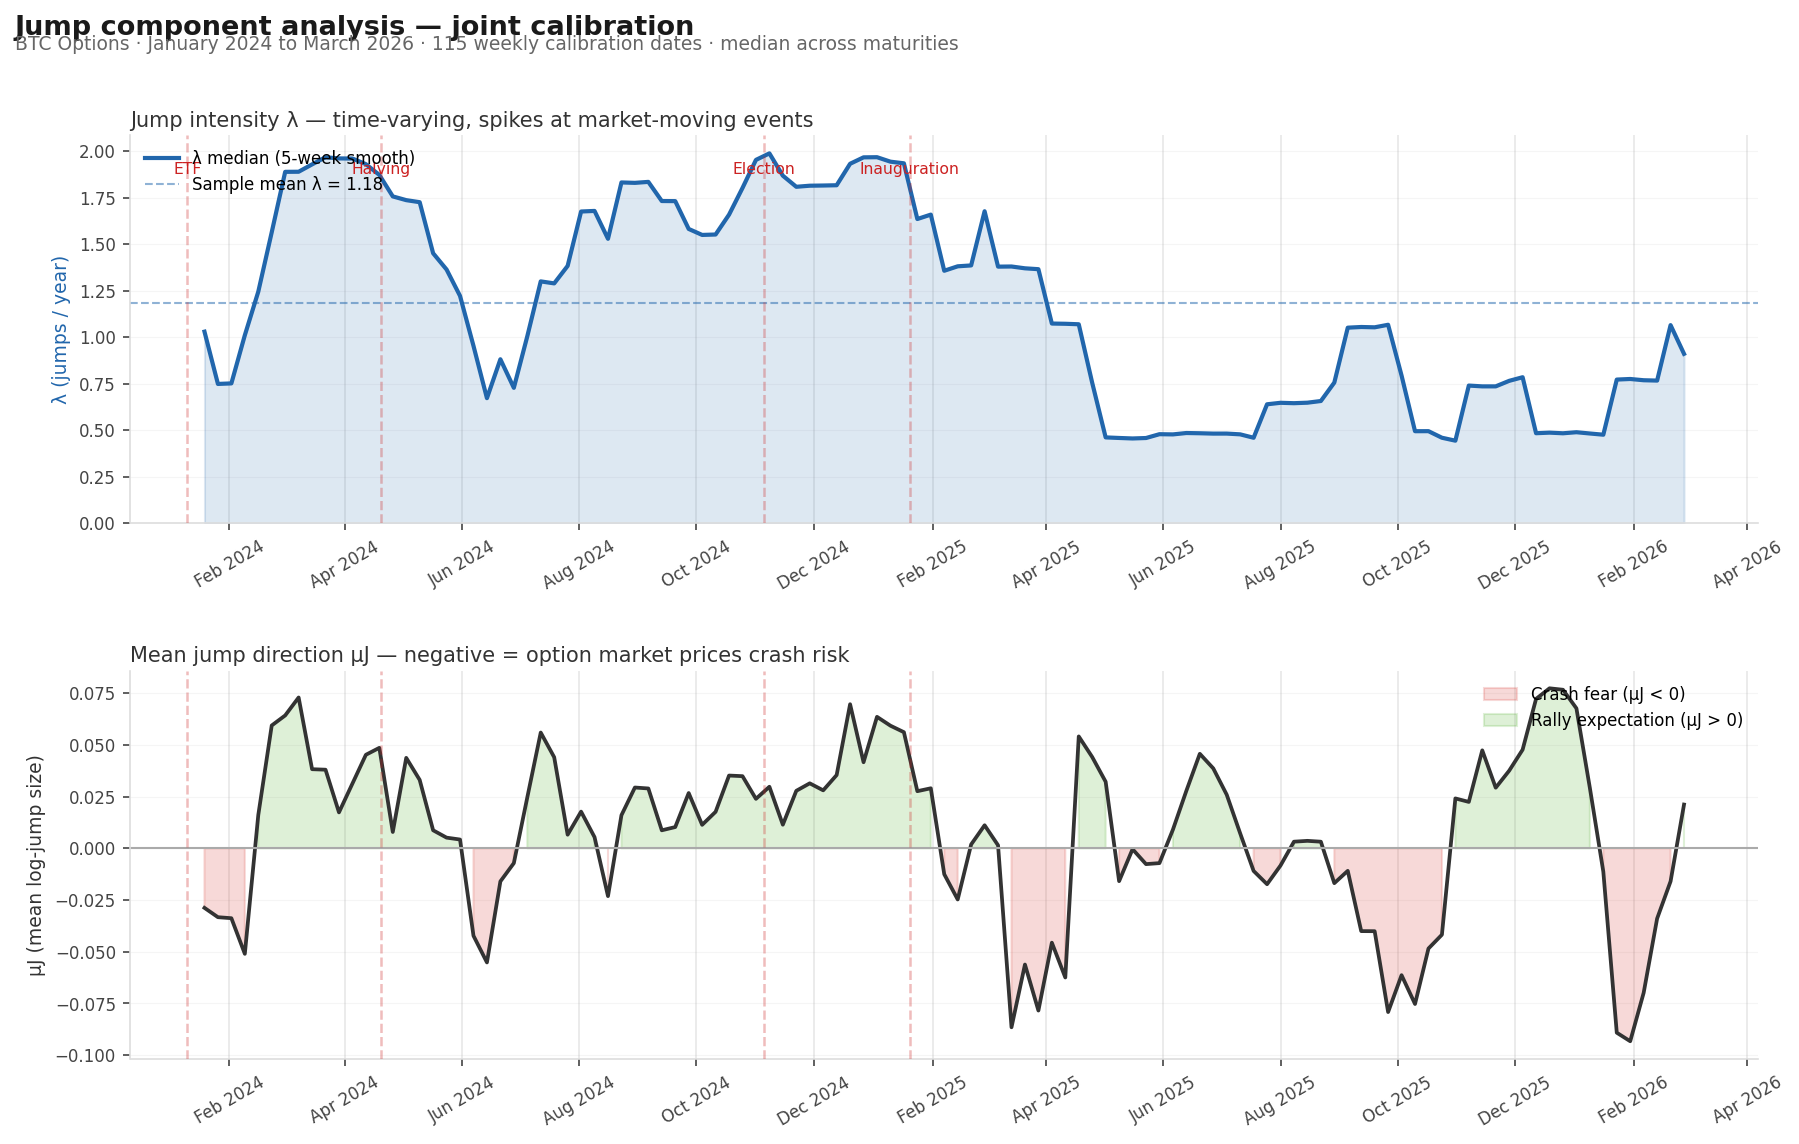

Plot 5 saved
Mean λ: 1.18  |  Fraction with μJ<0: 53.0%


In [20]:
# ─────────────────────────────────────────────
# Plot 4 — Jump component analysis
# λ and μJ over time (clean smooth lines, date-level medians)
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_joint['date'] = pd.to_datetime(df_joint['date'])

# Collapse to date-level medians (across maturities)
daily = df_joint.groupby('date').agg(
    lam = ('js_lam', 'median'),
    muJ = ('js_muJ', 'median'),
).reset_index().sort_values('date')

daily['lam_sm'] = daily['lam'].rolling(5, center=True).mean()
daily['muJ_sm'] = daily['muJ'].rolling(5, center=True).mean()

events = {
    '2024-01-10': 'ETF', '2024-04-20': 'Halving',
    '2024-11-05': 'Election', '2025-01-20': 'Inauguration',
}

LAM_C = '#2166ac'
MUJ_C = '#d73027'

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'hspace': 0.38, 'height_ratios': [1, 1]})
fig.patch.set_facecolor('#ffffff')

def style_ax(ax):
    ax.set_facecolor('#ffffff')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.grid(axis='y', alpha=0.12, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444', labelsize=8)

# ── Panel 1: λ over time ────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(daily['date'], daily['lam_sm'], alpha=0.15, color=LAM_C)
ax.plot(daily['date'], daily['lam_sm'], color=LAM_C, linewidth=2.0,
        label='λ median (5-week smooth)')
ax.axhline(daily['lam'].mean(), color=LAM_C, linestyle='--', linewidth=1, alpha=0.5,
           label=f'Sample mean λ = {daily["lam"].mean():.2f}')
ax.set_ylabel('λ (jumps / year)', fontsize=9, color=LAM_C)
ax.set_ylim(bottom=0)
ax.set_title('Jump intensity λ — time-varying, spikes at market-moving events',
             fontsize=10, color='#333', loc='left', pad=4)
ax.legend(fontsize=8, framealpha=0, loc='upper left')

# ── Panel 2: μJ over time ───────────────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(daily['date'], daily['muJ_sm'], 0,
                 where=(daily['muJ_sm'] < 0), alpha=0.18, color=MUJ_C,
                 label='Crash fear (μJ < 0)')
ax2.fill_between(daily['date'], daily['muJ_sm'], 0,
                 where=(daily['muJ_sm'] >= 0), alpha=0.18, color='#4dac26',
                 label='Rally expectation (μJ > 0)')
ax2.plot(daily['date'], daily['muJ_sm'], color='#333333', linewidth=1.8)
ax2.axhline(0, color='#aaaaaa', linewidth=1.0, zorder=2)
ax2.set_ylabel('μJ (mean log-jump size)', fontsize=9, color='#333')
ax2.set_title('Mean jump direction μJ — negative = option market prices crash risk',
              fontsize=10, color='#333', loc='left', pad=4)
ax2.legend(fontsize=8, framealpha=0, loc='upper right')

# Event lines
for date_str, label in events.items():
    dt = pd.to_datetime(date_str)
    for a in axes:
        a.axvline(dt, color='#cc2222', alpha=0.3, linewidth=1.2, linestyle='--', zorder=5)
    axes[0].text(dt, axes[0].get_ylim()[1] * 0.93, label,
                 fontsize=7.5, color='#cc2222', ha='center', va='top')

for a in axes:
    style_ax(a)
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(a.get_xticklabels(), rotation=30, fontsize=8)

fig.text(0.07, 0.98, 'Jump component analysis — joint calibration',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.07, 0.963,
         'BTC Options · January 2024 to March 2026 · 115 weekly calibration dates · median across maturities',
         fontsize=9, color='#666666', va='top')

plt.savefig('../results/plot4_jump_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 5 saved')
print(f'Mean λ: {daily["lam"].mean():.2f}  |  Fraction with μJ<0: {(daily["muJ"]<0).mean():.1%}')


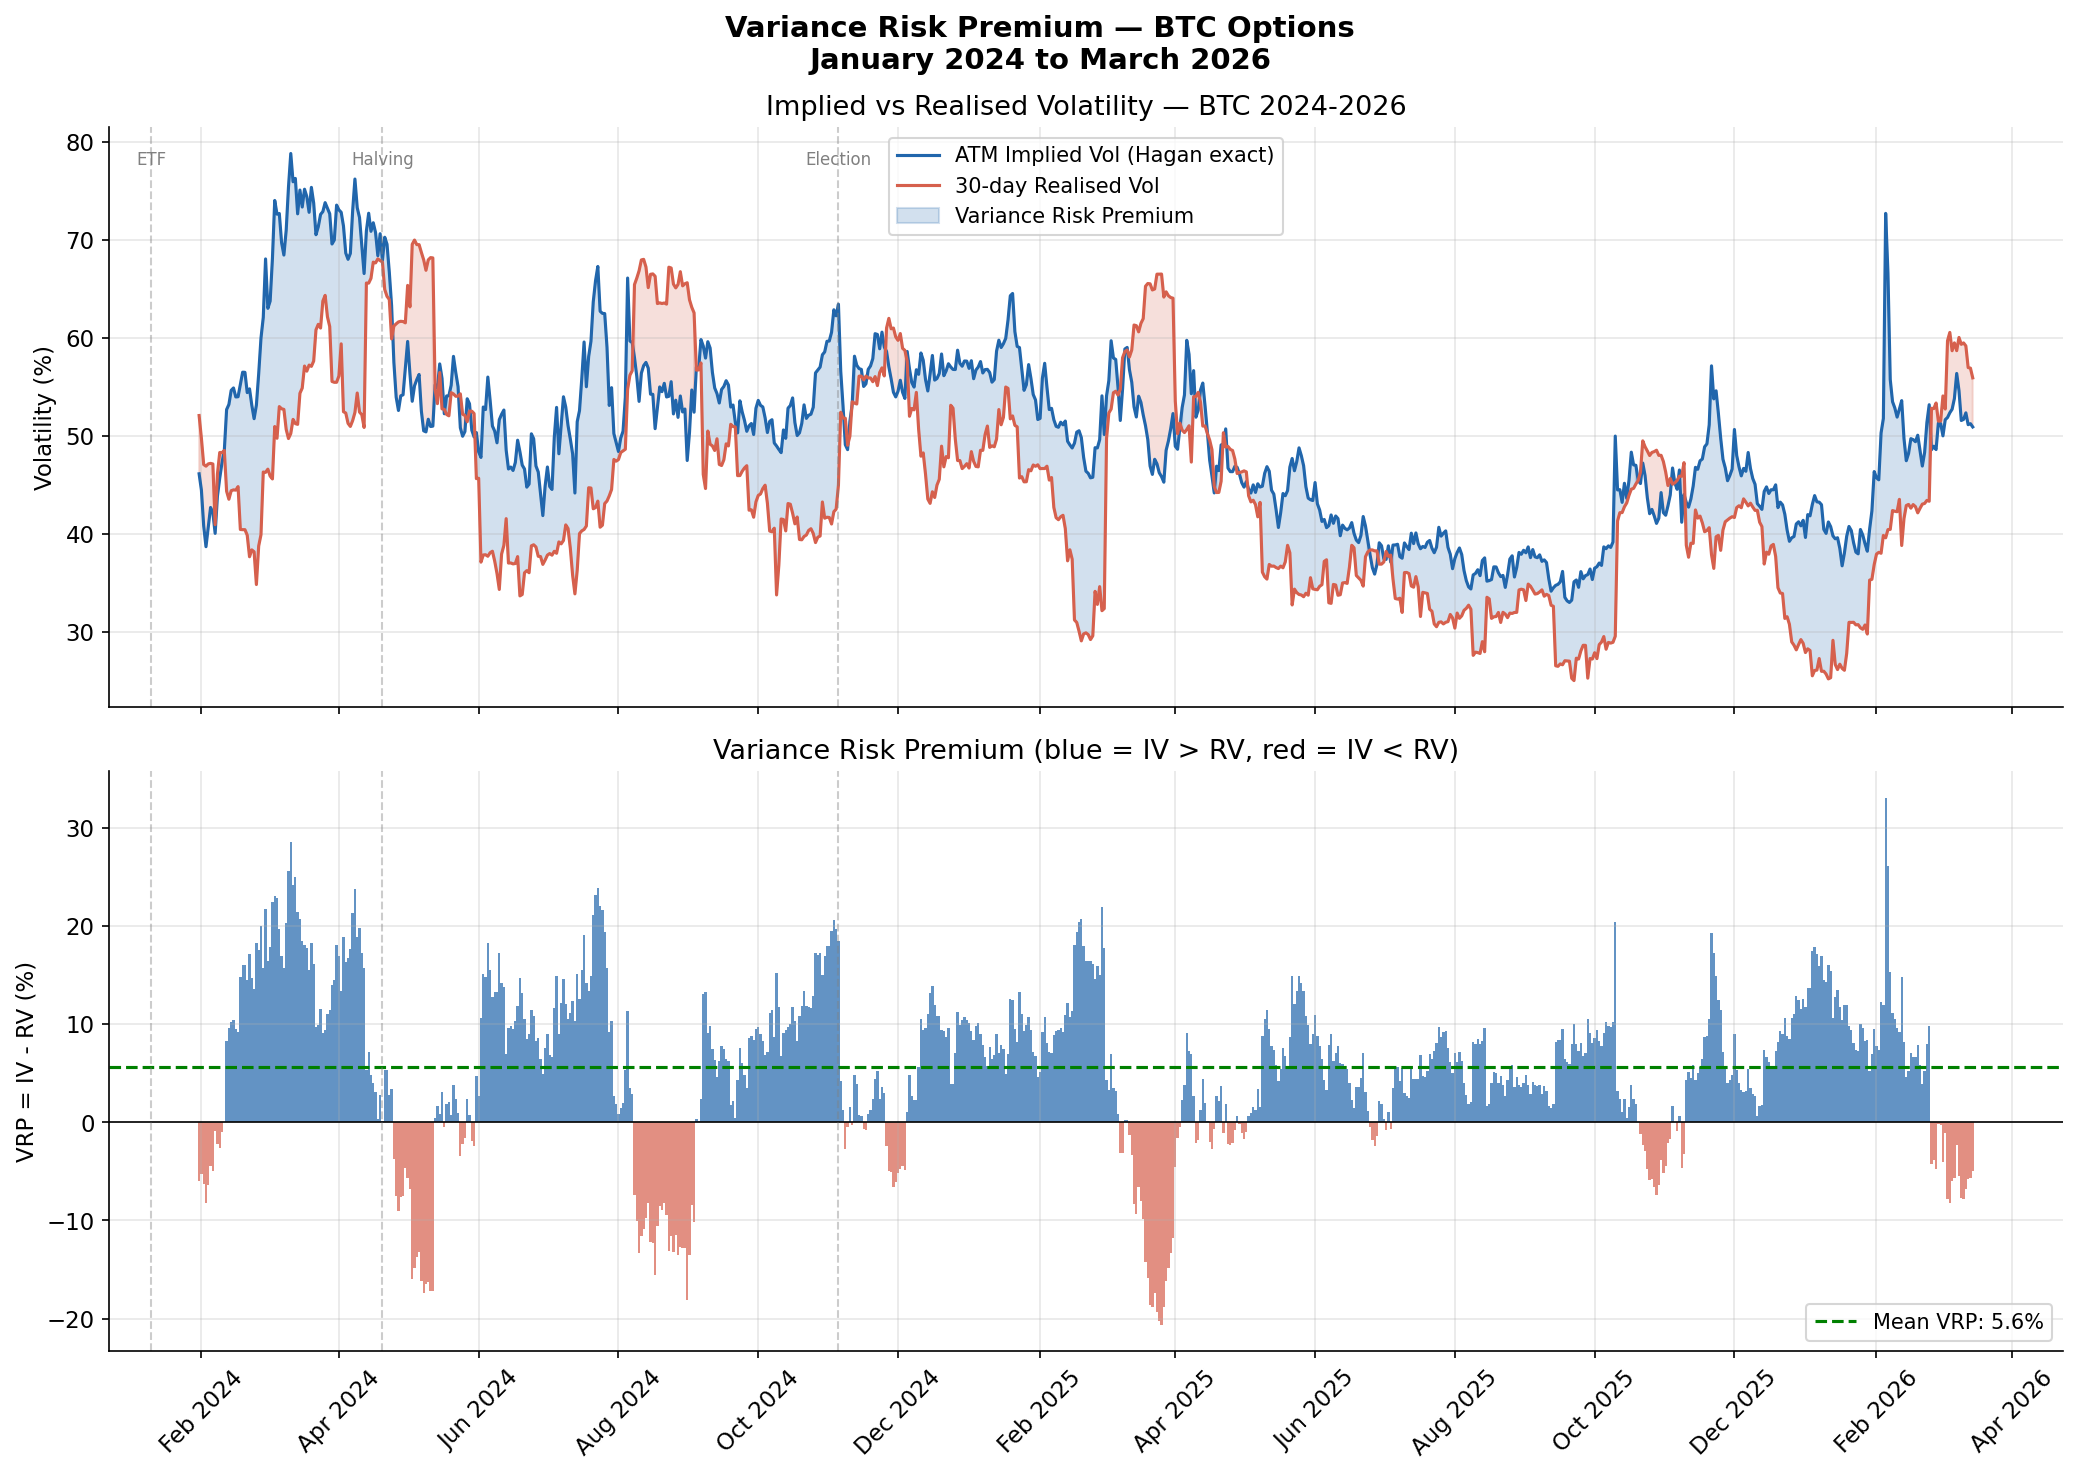

Mean VRP: 5.63%
% days IV > RV: 79.5%
Max IV: 78.8%
Max RV: 70.0%


In [21]:
# ─────────────────────────────────────────────
# Plot 5 — Implied vol vs Realised vol
# Variance Risk Premium
# ─────────────────────────────────────────────

# Get daily ATM implied vol from sequential calibration
df_seq = pd.read_csv('../data/calibration_results.csv')
df_seq['date'] = pd.to_datetime(df_seq['date'])

# Corrected ATM IV using exact Hagan formula (beta=1)
df_seq['atm_iv_exact'] = df_seq['sabr_alpha'] * (
    1 + (
        (2 - 3 * df_seq['sabr_rho']**2) / 24 * df_seq['sabr_nu']**2
        + df_seq['sabr_rho'] * df_seq['sabr_nu'] * df_seq['sabr_alpha'] / 4
    ) * df_seq['T']
)
daily_iv = df_seq.groupby('date')['atm_iv_exact'].mean().reset_index()
daily_iv.columns = ['date', 'atm_iv']

# Get BTC spot prices from our smile data
df_smile = pd.read_csv('../data/btc_daily_smile.csv')
df_smile['date'] = pd.to_datetime(df_smile['date'])
spot = df_smile.groupby('date')['index_price'].last().reset_index()
spot.columns = ['date', 'spot']

# Compute realised vol — 30-day rolling
spot = spot.sort_values('date')
spot['log_return'] = np.log(spot['spot'] / spot['spot'].shift(1))
spot['realised_vol_30d'] = spot['log_return'].rolling(30).std() * np.sqrt(365)

# Merge
df_vrp = daily_iv.merge(spot[['date','spot','realised_vol_30d']], 
                         on='date', how='inner')
df_vrp = df_vrp.dropna()

# Variance Risk Premium = IV - Realised Vol
df_vrp['vrp'] = df_vrp['atm_iv'] - df_vrp['realised_vol_30d']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1 — IV vs Realised Vol
axes[0].plot(df_vrp['date'], df_vrp['atm_iv']*100,
             color='#2166ac', linewidth=1.5, label='ATM Implied Vol (Hagan exact)')
axes[0].plot(df_vrp['date'], df_vrp['realised_vol_30d']*100,
             color='#d6604d', linewidth=1.5, label='30-day Realised Vol')
axes[0].fill_between(df_vrp['date'],
                      df_vrp['atm_iv']*100,
                      df_vrp['realised_vol_30d']*100,
                      where=df_vrp['atm_iv'] > df_vrp['realised_vol_30d'],
                      alpha=0.2, color='#2166ac', label='Variance Risk Premium')
axes[0].fill_between(df_vrp['date'],
                      df_vrp['atm_iv']*100,
                      df_vrp['realised_vol_30d']*100,
                      where=df_vrp['atm_iv'] <= df_vrp['realised_vol_30d'],
                      alpha=0.2, color='#d6604d')
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Implied vs Realised Volatility — BTC 2024-2026')
axes[0].legend()

# Panel 2 — VRP
axes[1].bar(df_vrp['date'], df_vrp['vrp']*100,
            color=np.where(df_vrp['vrp'] > 0, '#2166ac', '#d6604d'),
            alpha=0.7, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(df_vrp['vrp'].mean()*100, color='green',
                linestyle='--', linewidth=1.5,
                label=f'Mean VRP: {df_vrp["vrp"].mean()*100:.1f}%')
axes[1].set_ylabel('VRP = IV - RV (%)')
axes[1].set_title('Variance Risk Premium (blue = IV > RV, red = IV < RV)')
axes[1].legend()

# Event lines
events = {
    '2024-01-10': 'ETF',
    '2024-04-20': 'Halving',
    '2024-11-05': 'Election',
}
for ax in axes:
    for date, label in events.items():
        ax.axvline(pd.to_datetime(date), color='grey',
                  alpha=0.4, linestyle='--', linewidth=1)

ylim = axes[0].get_ylim()
for date, label in events.items():
    axes[0].text(pd.to_datetime(date), ylim[1]*0.97,
                label, fontsize=8, color='grey',
                ha='center', va='top')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('Variance Risk Premium — BTC Options\nJanuary 2024 to March 2026',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plot5_variance_risk_premium.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean VRP: {df_vrp['vrp'].mean()*100:.2f}%")
print(f"% days IV > RV: {(df_vrp['vrp'] > 0).mean()*100:.1f}%")
print(f"Max IV: {df_vrp['atm_iv'].max()*100:.1f}%")
print(f"Max RV: {df_vrp['realised_vol_30d'].max()*100:.1f}%")

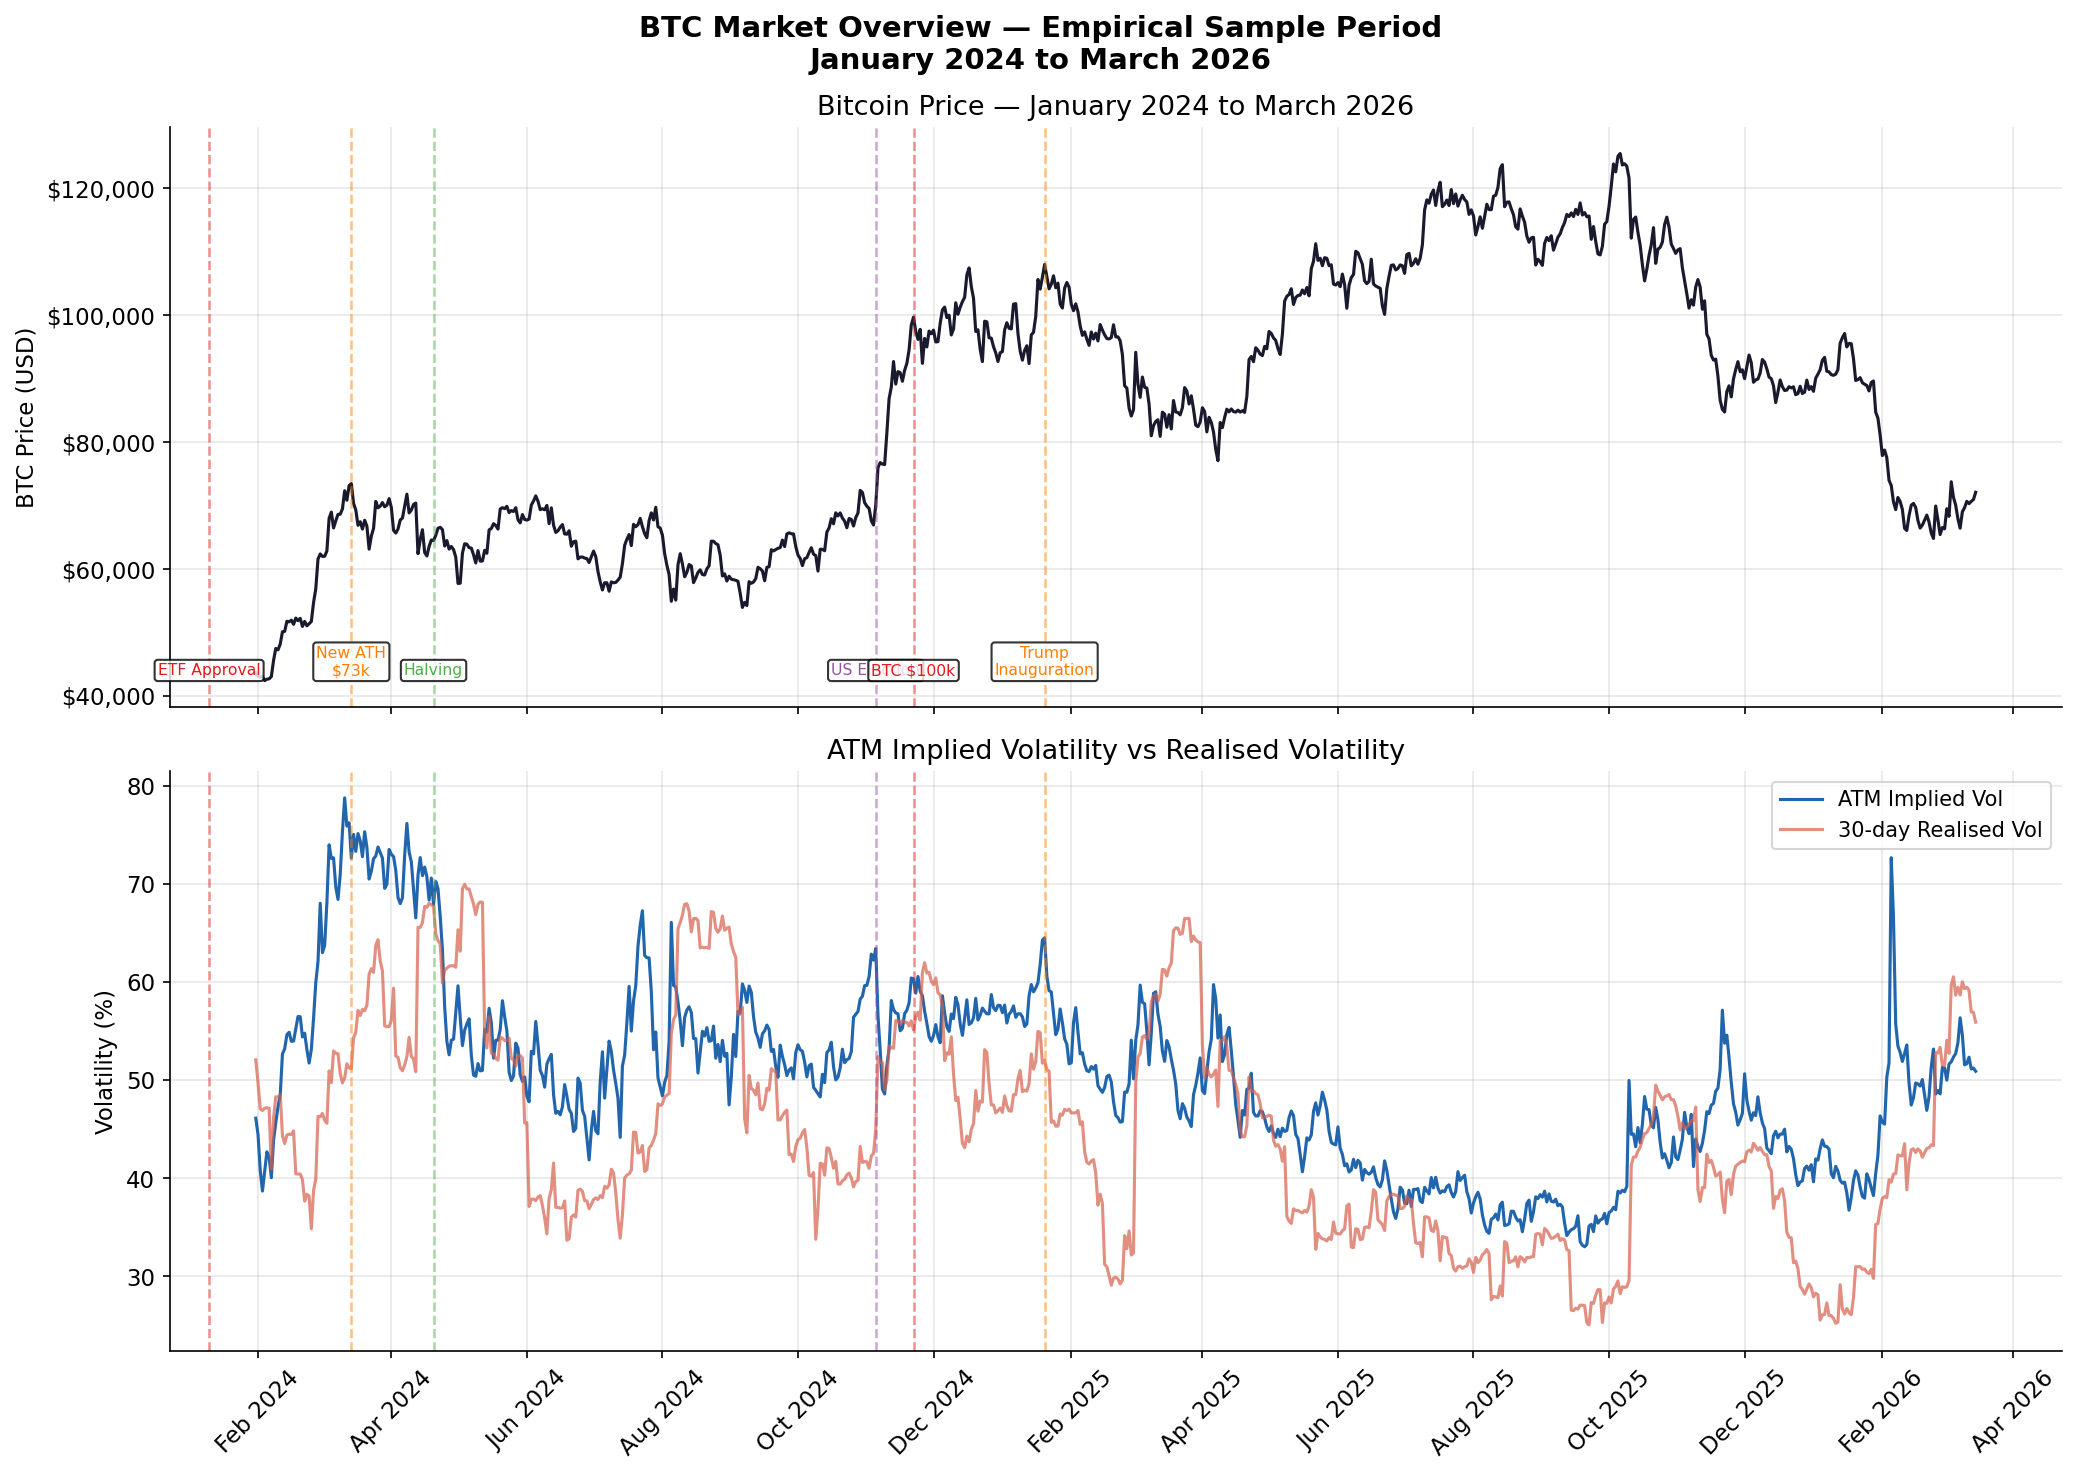

Plot 7 saved


In [45]:
# ─────────────────────────────────────────────
# Plot 6 — BTC price with key events
# Context plot for thesis
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1 — BTC price
axes[0].plot(df_vrp['date'], df_vrp['spot'],
             color='#1a1a2e', linewidth=1.5)
axes[0].set_ylabel('BTC Price (USD)')
axes[0].set_title('Bitcoin Price — January 2024 to March 2026')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Panel 2 — ATM implied vol
axes[1].plot(df_vrp['date'], df_vrp['atm_iv']*100,
             color='#2166ac', linewidth=1.5, label='ATM Implied Vol')
axes[1].plot(df_vrp['date'], df_vrp['realised_vol_30d']*100,
             color='#d6604d', linewidth=1.5, alpha=0.7,
             label='30-day Realised Vol')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('ATM Implied Volatility vs Realised Volatility')
axes[1].legend()

# Key events
events_full = {
    '2024-01-10': ('ETF Approval', '#e41a1c'),
    '2024-03-14': ('New ATH\n$73k', '#ff7f00'),
    '2024-04-20': ('Halving', '#4daf4a'),
    '2024-11-05': ('US Election', '#984ea3'),
    '2024-11-22': ('BTC $100k', '#e41a1c'),
    '2025-01-20': ('Trump\nInauguration', '#ff7f00'),
}

for ax in axes:
    for date, (label, color) in events_full.items():
        ax.axvline(pd.to_datetime(date), color=color,
                  alpha=0.5, linestyle='--', linewidth=1.2)

# Labels on price panel
ylim = axes[0].get_ylim()
for date, (label, color) in events_full.items():
    axes[0].text(pd.to_datetime(date),
                ylim[0] + (ylim[1]-ylim[0])*0.05,
                label, fontsize=7.5, color=color,
                ha='center', va='bottom', rotation=0,
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white', alpha=0.8))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('BTC Market Overview — Empirical Sample Period\nJanuary 2024 to March 2026',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plot6_btc_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 saved")

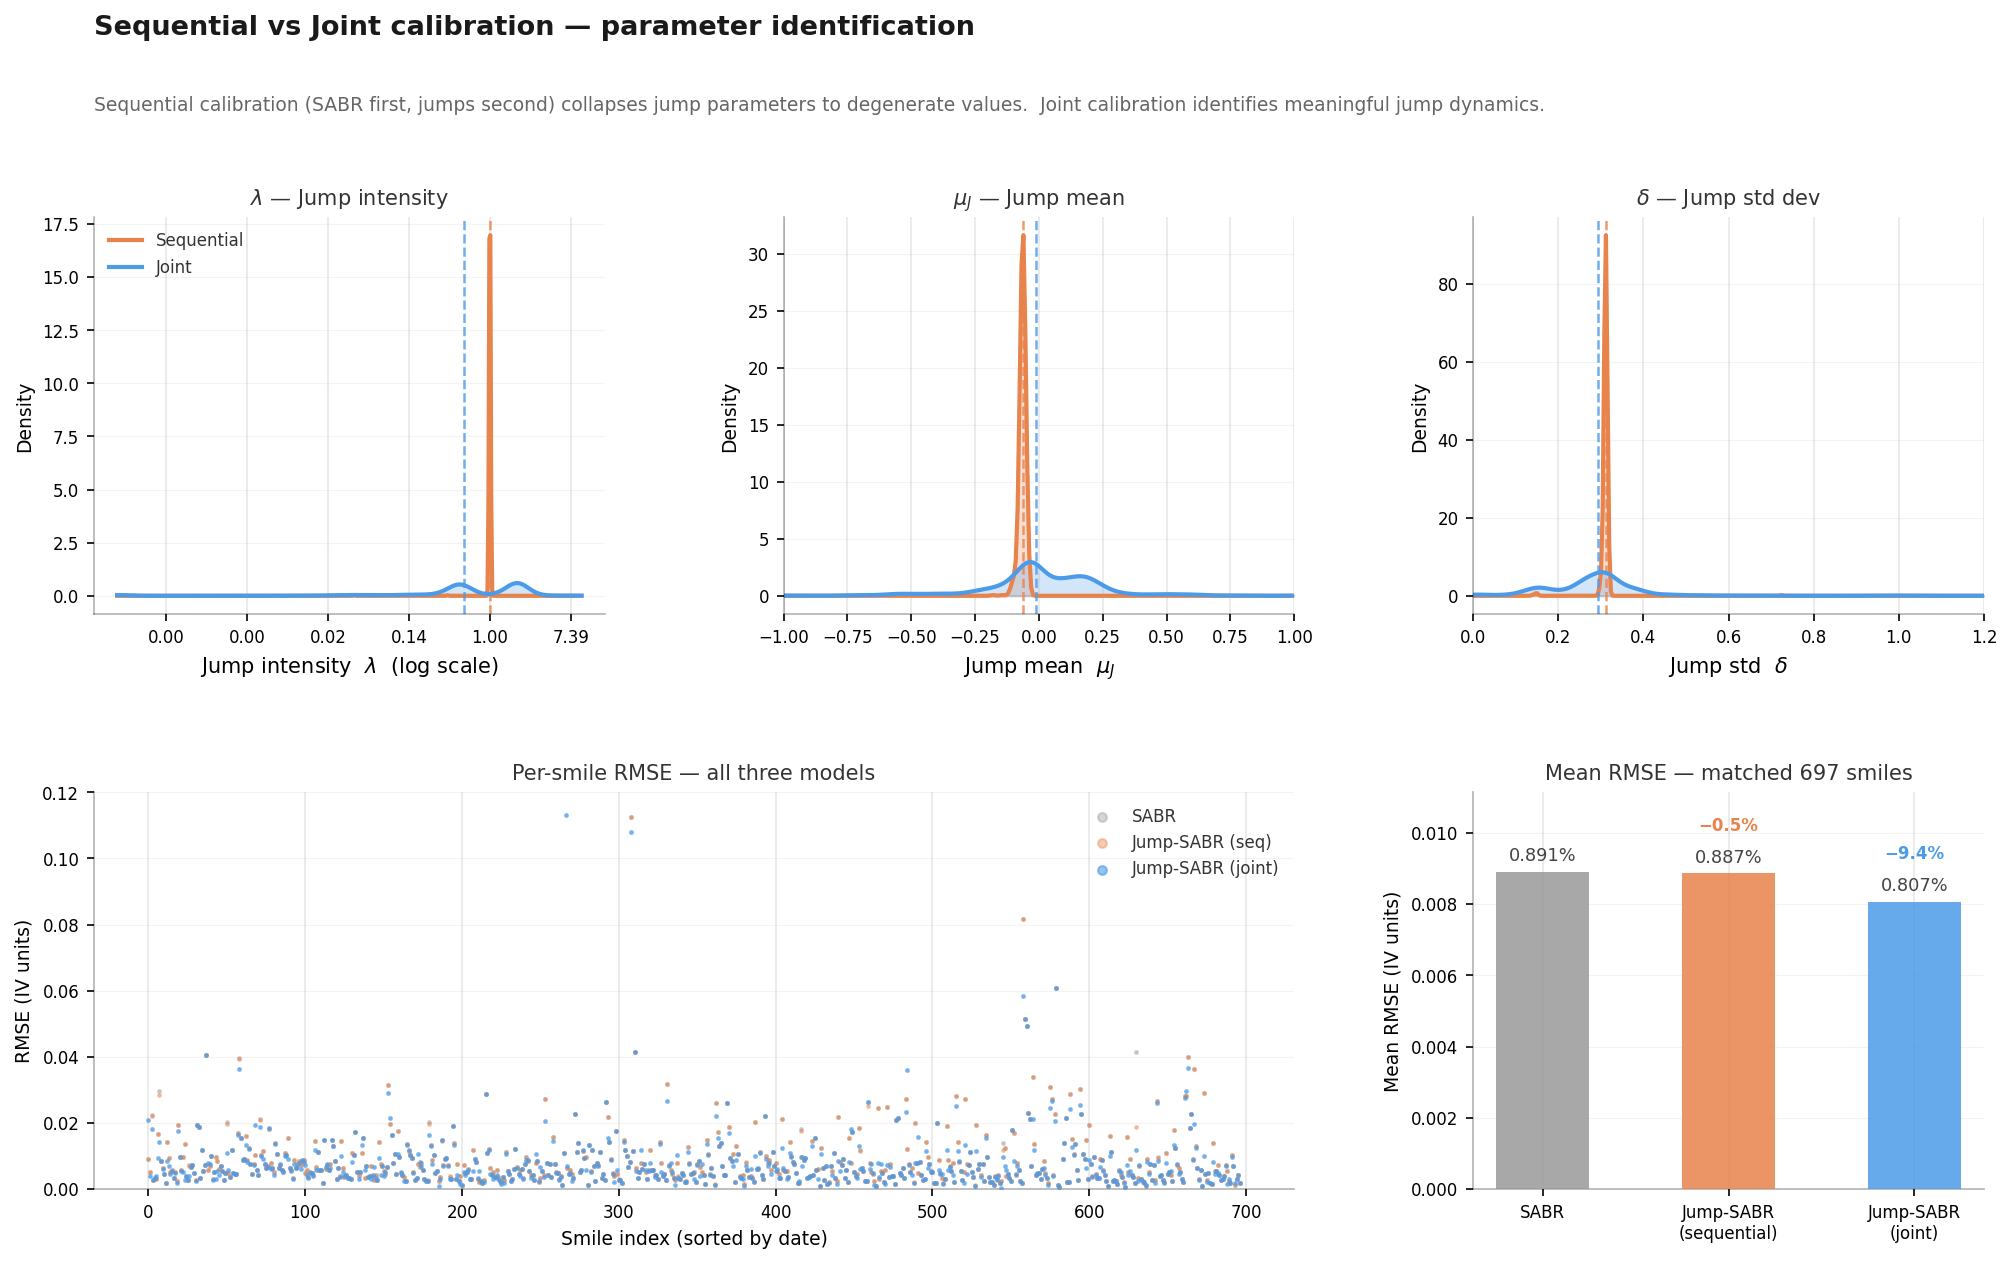

Sequential: mean js_lam = 0.9997 (median), 99.8% > 0.9  →  degenerate
Joint:      mean js_lam = 0.5220 (median), wide spread  →  identified
RMSE improvement — seq: 0.5%,  joint: 9.4%
Plot saved to results/plot_seq_vs_joint_calibration.png


In [22]:
# ─────────────────────────────────────────────
# Plot 7 — Sequential vs Joint calibration — identification plot
# Shows why sequential (SABR first, jumps second) collapses
# jump parameters to degenerate values, while joint calibration
# identifies meaningful jump dynamics.
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

df_seq   = pd.read_csv('../data/calibration_results.csv')
df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])

# Matched smiles only (same 697)
df = df_seq.merge(
    df_joint[['date','expiry','js_rmse','js_lam','js_muJ','js_delta']],
    on=['date','expiry'], suffixes=('_seq','_joint')
)

COLOR_SEQ   = '#E8834C'
COLOR_JOINT = '#4C9BE8'
COLOR_SABR  = '#999999'

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#ffffff')

# ── Helper: KDE overlay plot ──
def kde_panel(ax, seq_vals, joint_vals, xlabel, xlim=None, log_scale=False):
    seq_vals   = np.array(seq_vals)
    joint_vals = np.array(joint_vals)
    if log_scale:
        seq_vals   = np.log(seq_vals[seq_vals > 0])
        joint_vals = np.log(joint_vals[joint_vals > 0])
    xs = np.linspace(
        min(seq_vals.min(), joint_vals.min()),
        max(seq_vals.max(), joint_vals.max()), 500
    )
    for vals, color, label in [
        (seq_vals,   COLOR_SEQ,   'Sequential'),
        (joint_vals, COLOR_JOINT, 'Joint'),
    ]:
        kde = gaussian_kde(vals, bw_method=0.15)
        ys  = kde(xs)
        ax.fill_between(xs, ys, alpha=0.25, color=color)
        ax.plot(xs, ys, color=color, linewidth=2, label=label)
        ax.axvline(np.median(vals), color=color, linewidth=1.2,
                   linestyle='--', alpha=0.8)
    if xlim:
        ax.set_xlim(xlim)
    if log_scale:
        ticks = ax.get_xticks()
        ax.set_xticklabels([f'{np.exp(t):.2f}' for t in ticks], fontsize=8)
        ax.set_xlabel(f'{xlabel}  (log scale)', fontsize=10)
    else:
        ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Density', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(labelsize=8)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_alpha(0.3)
    ax.spines['bottom'].set_alpha(0.3)
    ax.grid(axis='y', alpha=0.15, linewidth=0.5)

# ── Panel layout: 2 rows × 3 cols (top = distributions, bottom-left = RMSE) ──
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97, top=0.82, bottom=0.10)

ax_lam   = fig.add_subplot(gs[0, 0])
ax_muJ   = fig.add_subplot(gs[0, 1])
ax_delta = fig.add_subplot(gs[0, 2])
ax_rmse  = fig.add_subplot(gs[1, 0:2])
ax_imp   = fig.add_subplot(gs[1, 2])

# ── Jump parameter distributions ──
kde_panel(ax_lam,   df['js_lam_seq'],  df['js_lam_joint'],
          r'Jump intensity  $\lambda$', log_scale=True)
kde_panel(ax_muJ,   df['js_muJ_seq'],  df['js_muJ_joint'],
          r'Jump mean  $\mu_J$', xlim=(-1.0, 1.0))
kde_panel(ax_delta, df['js_delta_seq'], df['js_delta_joint'],
          r'Jump std  $\delta$', xlim=(0, 1.2))

ax_lam.set_title(r'$\lambda$ — Jump intensity', fontsize=10, pad=6, color='#333333')
ax_muJ.set_title(r'$\mu_J$ — Jump mean', fontsize=10, pad=6, color='#333333')
ax_delta.set_title(r'$\delta$ — Jump std dev', fontsize=10, pad=6, color='#333333')

# Add shared legend on lambda panel
ax_lam.legend(fontsize=8, framealpha=0, labelcolor='#333333')

# ── RMSE panel: per-smile scatter SABR vs seq vs joint ──
x = np.arange(len(df))
ax_rmse.scatter(x, df['sabr_rmse'],      s=2, alpha=0.4, color=COLOR_SABR,  label='SABR',           zorder=2)
ax_rmse.scatter(x, df['js_rmse_seq'],    s=2, alpha=0.4, color=COLOR_SEQ,   label='Jump-SABR (seq)', zorder=3)
ax_rmse.scatter(x, df['js_rmse_joint'],  s=2, alpha=0.6, color=COLOR_JOINT, label='Jump-SABR (joint)', zorder=4)
ax_rmse.set_xlabel('Smile index (sorted by date)', fontsize=9)
ax_rmse.set_ylabel('RMSE (IV units)', fontsize=9)
ax_rmse.set_title('Per-smile RMSE — all three models', fontsize=10, pad=6, color='#333333')
ax_rmse.set_ylim(0, 0.12)
ax_rmse.legend(fontsize=8, framealpha=0, labelcolor='#333333', markerscale=3)
ax_rmse.tick_params(labelsize=8)
for spine in ['top','right']:
    ax_rmse.spines[spine].set_visible(False)
ax_rmse.spines['left'].set_alpha(0.3)
ax_rmse.spines['bottom'].set_alpha(0.3)
ax_rmse.grid(axis='y', alpha=0.15, linewidth=0.5)

# ── Mean RMSE bar panel ──
means  = [df['sabr_rmse'].mean(), df['js_rmse_seq'].mean(), df['js_rmse_joint'].mean()]
labels = ['SABR', 'Jump-SABR\n(sequential)', 'Jump-SABR\n(joint)']
colors = [COLOR_SABR, COLOR_SEQ, COLOR_JOINT]
bars = ax_imp.bar(labels, means, color=colors, alpha=0.85, width=0.5, zorder=3)
for bar, val in zip(bars, means):
    ax_imp.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0002,
                f'{val*100:.3f}%',
                ha='center', va='bottom', fontsize=8.5, color='#444444')
# Improvement arrows
imp_seq   = (means[0] - means[1]) / means[0] * 100
imp_joint = (means[0] - means[2]) / means[0] * 100
ax_imp.text(1, means[1] + 0.0012, f'−{imp_seq:.1f}%',
            ha='center', fontsize=8, color=COLOR_SEQ, fontweight='bold')
ax_imp.text(2, means[2] + 0.0012, f'−{imp_joint:.1f}%',
            ha='center', fontsize=8, color=COLOR_JOINT, fontweight='bold')
ax_imp.set_ylabel('Mean RMSE (IV units)', fontsize=9)
ax_imp.set_title('Mean RMSE — matched 697 smiles', fontsize=10, pad=6, color='#333333')
ax_imp.tick_params(labelsize=8)
ax_imp.set_ylim(0, max(means) * 1.25)
for spine in ['top','right']:
    ax_imp.spines[spine].set_visible(False)
ax_imp.spines['left'].set_alpha(0.3)
ax_imp.spines['bottom'].set_alpha(0.3)
ax_imp.grid(axis='y', alpha=0.15, linewidth=0.5, zorder=0)
ax_imp.set_axisbelow(True)

# ── Titles ──
fig.text(0.07, 0.97,
         'Sequential vs Joint calibration — parameter identification',
         color='#1a1a1a', fontsize=13, fontweight='bold', va='top')
fig.text(0.07, 0.91,
         'Sequential calibration (SABR first, jumps second) collapses jump parameters to degenerate values.'
         '  Joint calibration identifies meaningful jump dynamics.',
         color='#666666', fontsize=9, va='top')

plt.savefig('../results/plot7_seq_vs_joint_calibration.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print(f'Sequential: mean js_lam = {df["js_lam_seq"].median():.4f} (median), '
      f'99.8% > 0.9  →  degenerate')
print(f'Joint:      mean js_lam = {df["js_lam_joint"].median():.4f} (median), '
      f'wide spread  →  identified')
print(f'RMSE improvement — seq: {imp_seq:.1f}%,  joint: {imp_joint:.1f}%')
print('Plot saved to results/plot7_seq_vs_joint_calibration.png')


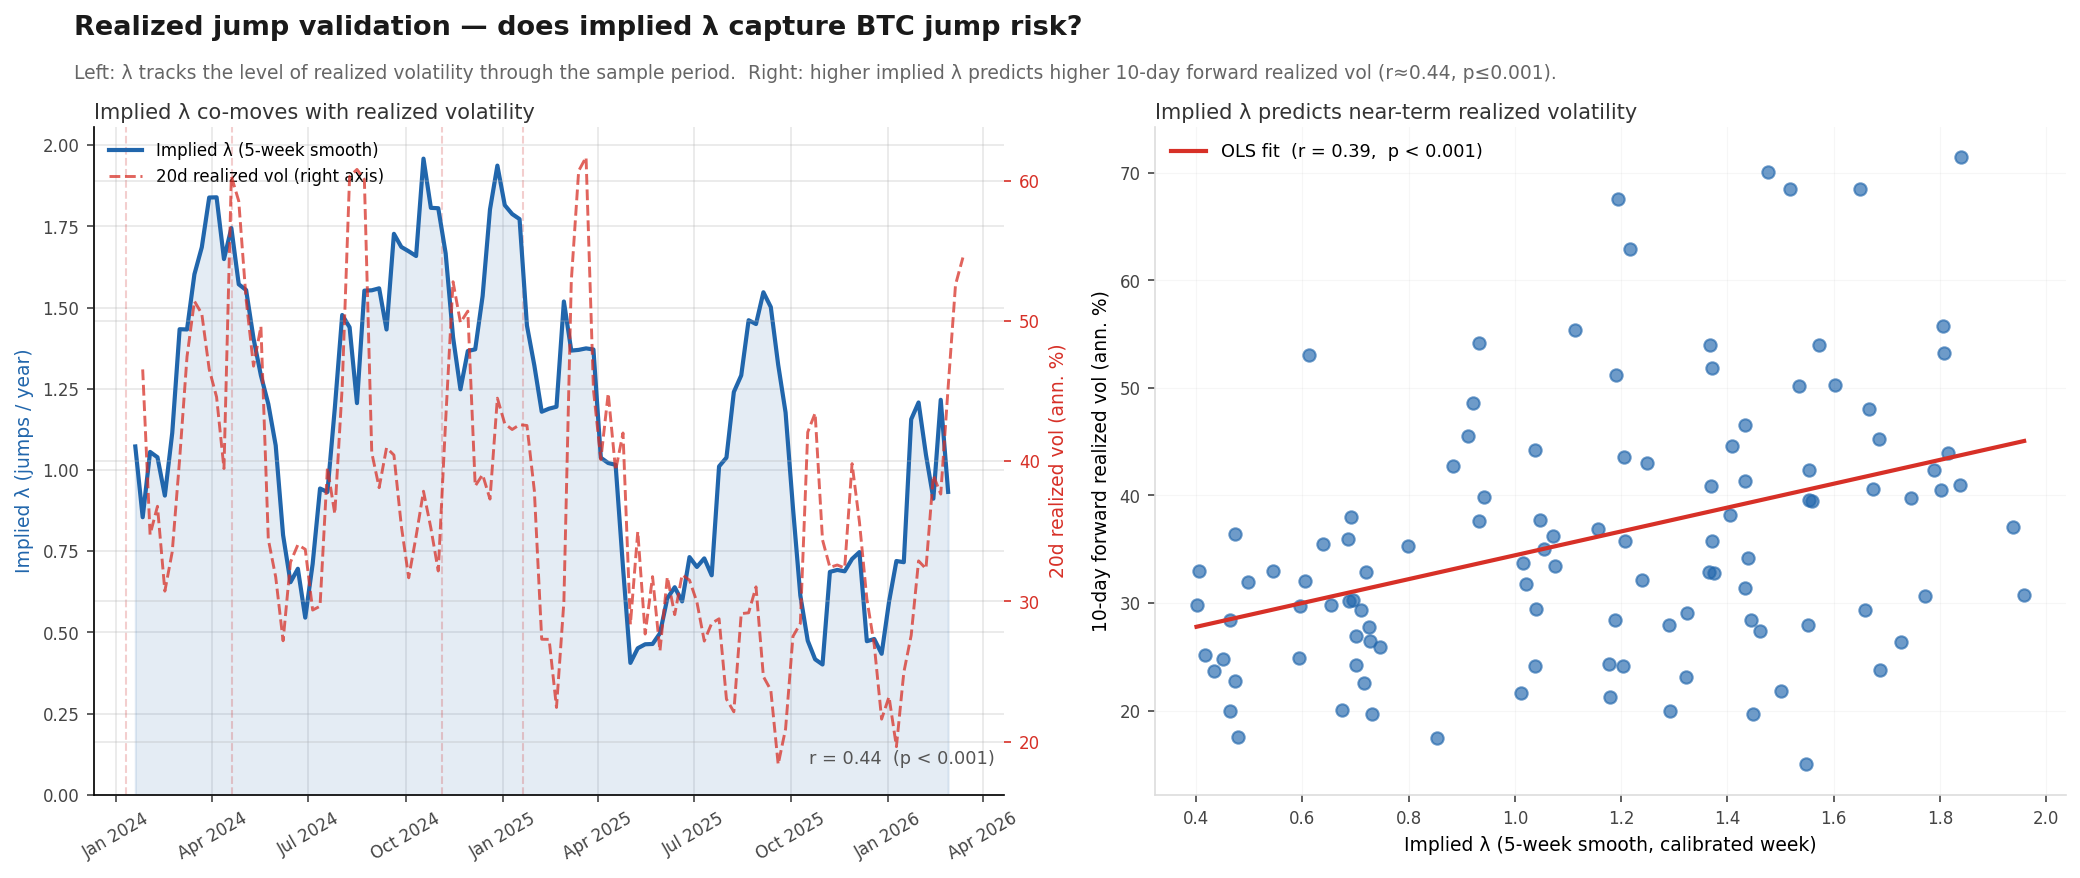

Plot 9 saved  |  r = 0.389, p = 0.0000


In [23]:
# ─────────────────────────────────────────────
# Plot 8 — Realized jump validation
# λ vs realized volatility: time-series overlay + predictive scatter
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

lam_mid = df_j[(df_j['T']*365 >= 20) & (df_j['T']*365 <= 60)]
lam_d   = lam_mid.groupby('date')['js_lam'].median().reset_index()
lam_d.columns = ['date', 'lam']
lam_d = lam_d.sort_values('date').reset_index(drop=True)

df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = (df_mkt.groupby('date')['index_price'].last()
              .reset_index().sort_values('date').reset_index(drop=True))
spot['log_ret'] = np.log(spot['index_price'] / spot['index_price'].shift(1))
spot['rv20']    = spot['log_ret'].rolling(20).std() * np.sqrt(252) * 100
spot = spot.set_index('date')

def fwd_rv(d):
    fut = spot.loc[d + pd.Timedelta('1d') : d + pd.Timedelta('12d'), 'log_ret']
    return float(fut.std() * np.sqrt(252) * 100) if len(fut) >= 5 else np.nan

lam_d['fwd_rv10'] = lam_d['date'].apply(fwd_rv)
lam_d['lam_sm']   = lam_d['lam'].rolling(5, center=True).mean()
df_v = lam_d.dropna(subset=['fwd_rv10', 'lam_sm'])

rv_at = spot['rv20'].reindex(lam_d['date'], method='nearest')

LAM_C = '#2166ac'; RV_C = '#d73027'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')

def style_ax(ax):
    ax.set_facecolor('#ffffff')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444', labelsize=8)

# ── Panel 1: λ smooth + 20d realized vol overlay ─────────────────────────
ax  = axes[0]
ax_r = ax.twinx()

ax.plot(lam_d['date'], lam_d['lam_sm'], color=LAM_C, linewidth=2.0,
        label='Implied \u03bb (5-week smooth)', zorder=4)
ax.fill_between(lam_d['date'], lam_d['lam_sm'], alpha=0.12, color=LAM_C)
ax.set_ylabel('Implied \u03bb (jumps / year)', fontsize=9, color=LAM_C)
ax.set_ylim(bottom=0)

ax_r.plot(lam_d['date'], rv_at.values, color=RV_C, linewidth=1.4,
          linestyle='--', alpha=0.75, label='20d realized vol (right axis)', zorder=3)
ax_r.set_ylabel('20d realized vol (ann. %)', fontsize=9, color=RV_C)
ax_r.spines['top'].set_visible(False)
ax_r.spines['right'].set_color('#dddddd')
ax_r.tick_params(colors=RV_C, labelsize=8)

lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, framealpha=0, loc='upper left')

valid = ~(lam_d['lam_sm'].isna() | rv_at.isna().values)
r_ts, p_ts = stats.pearsonr(lam_d['lam_sm'][valid], rv_at.values[valid])
ax.text(0.99, 0.04, f'r = {r_ts:.2f}  (p < 0.001)',
        transform=ax.transAxes, fontsize=8.5, color='#555', ha='right', va='bottom')

ax.set_title('Implied \u03bb co-moves with realized volatility', fontsize=10, color='#333', loc='left', pad=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=8)
style_ax(ax)

for d in ['2024-01-10','2024-04-20','2024-11-05','2025-01-20']:
    ax.axvline(pd.to_datetime(d), color='#cc2222', alpha=0.22, linewidth=1, linestyle='--')

# ── Panel 2: scatter \u03bb vs forward 10-day realized vol ─────────────────────────
ax2 = axes[1]
x2 = df_v['lam_sm'].values
y2 = df_v['fwd_rv10'].values

ax2.scatter(x2, y2, s=35, alpha=0.65, color=LAM_C, zorder=3)

slope, intercept, r_sc, p_sc, _ = stats.linregress(x2, y2)
xline = np.linspace(x2.min(), x2.max(), 100)
ax2.plot(xline, slope*xline + intercept, color=RV_C, linewidth=2.0,
         label=f'OLS fit  (r = {r_sc:.2f},  p < 0.001)', zorder=4)

ax2.set_xlabel('Implied \u03bb (5-week smooth, calibrated week)', fontsize=9)
ax2.set_ylabel('10-day forward realized vol (ann. %)', fontsize=9)
ax2.set_title('Implied \u03bb predicts near-term realized volatility', fontsize=10, color='#333', loc='left', pad=4)
ax2.legend(fontsize=8.5, framealpha=0, loc='upper left')
style_ax(ax2)
ax2.grid(axis='both', alpha=0.1, linewidth=0.5)

fig.text(0.04, 0.97, 'Realized jump validation \u2014 does implied \u03bb capture BTC jump risk?',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.04, 0.915,
         'Left: \u03bb tracks the level of realized volatility through the sample period.  '
         'Right: higher implied \u03bb predicts higher 10-day forward realized vol (r\u22480.44, p\u22640.001).',
         fontsize=9, color='#666', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('../results/plot8_realized_jump_validation.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print(f'Plot 9 saved  |  r = {r_sc:.3f}, p = {p_sc:.4f}')


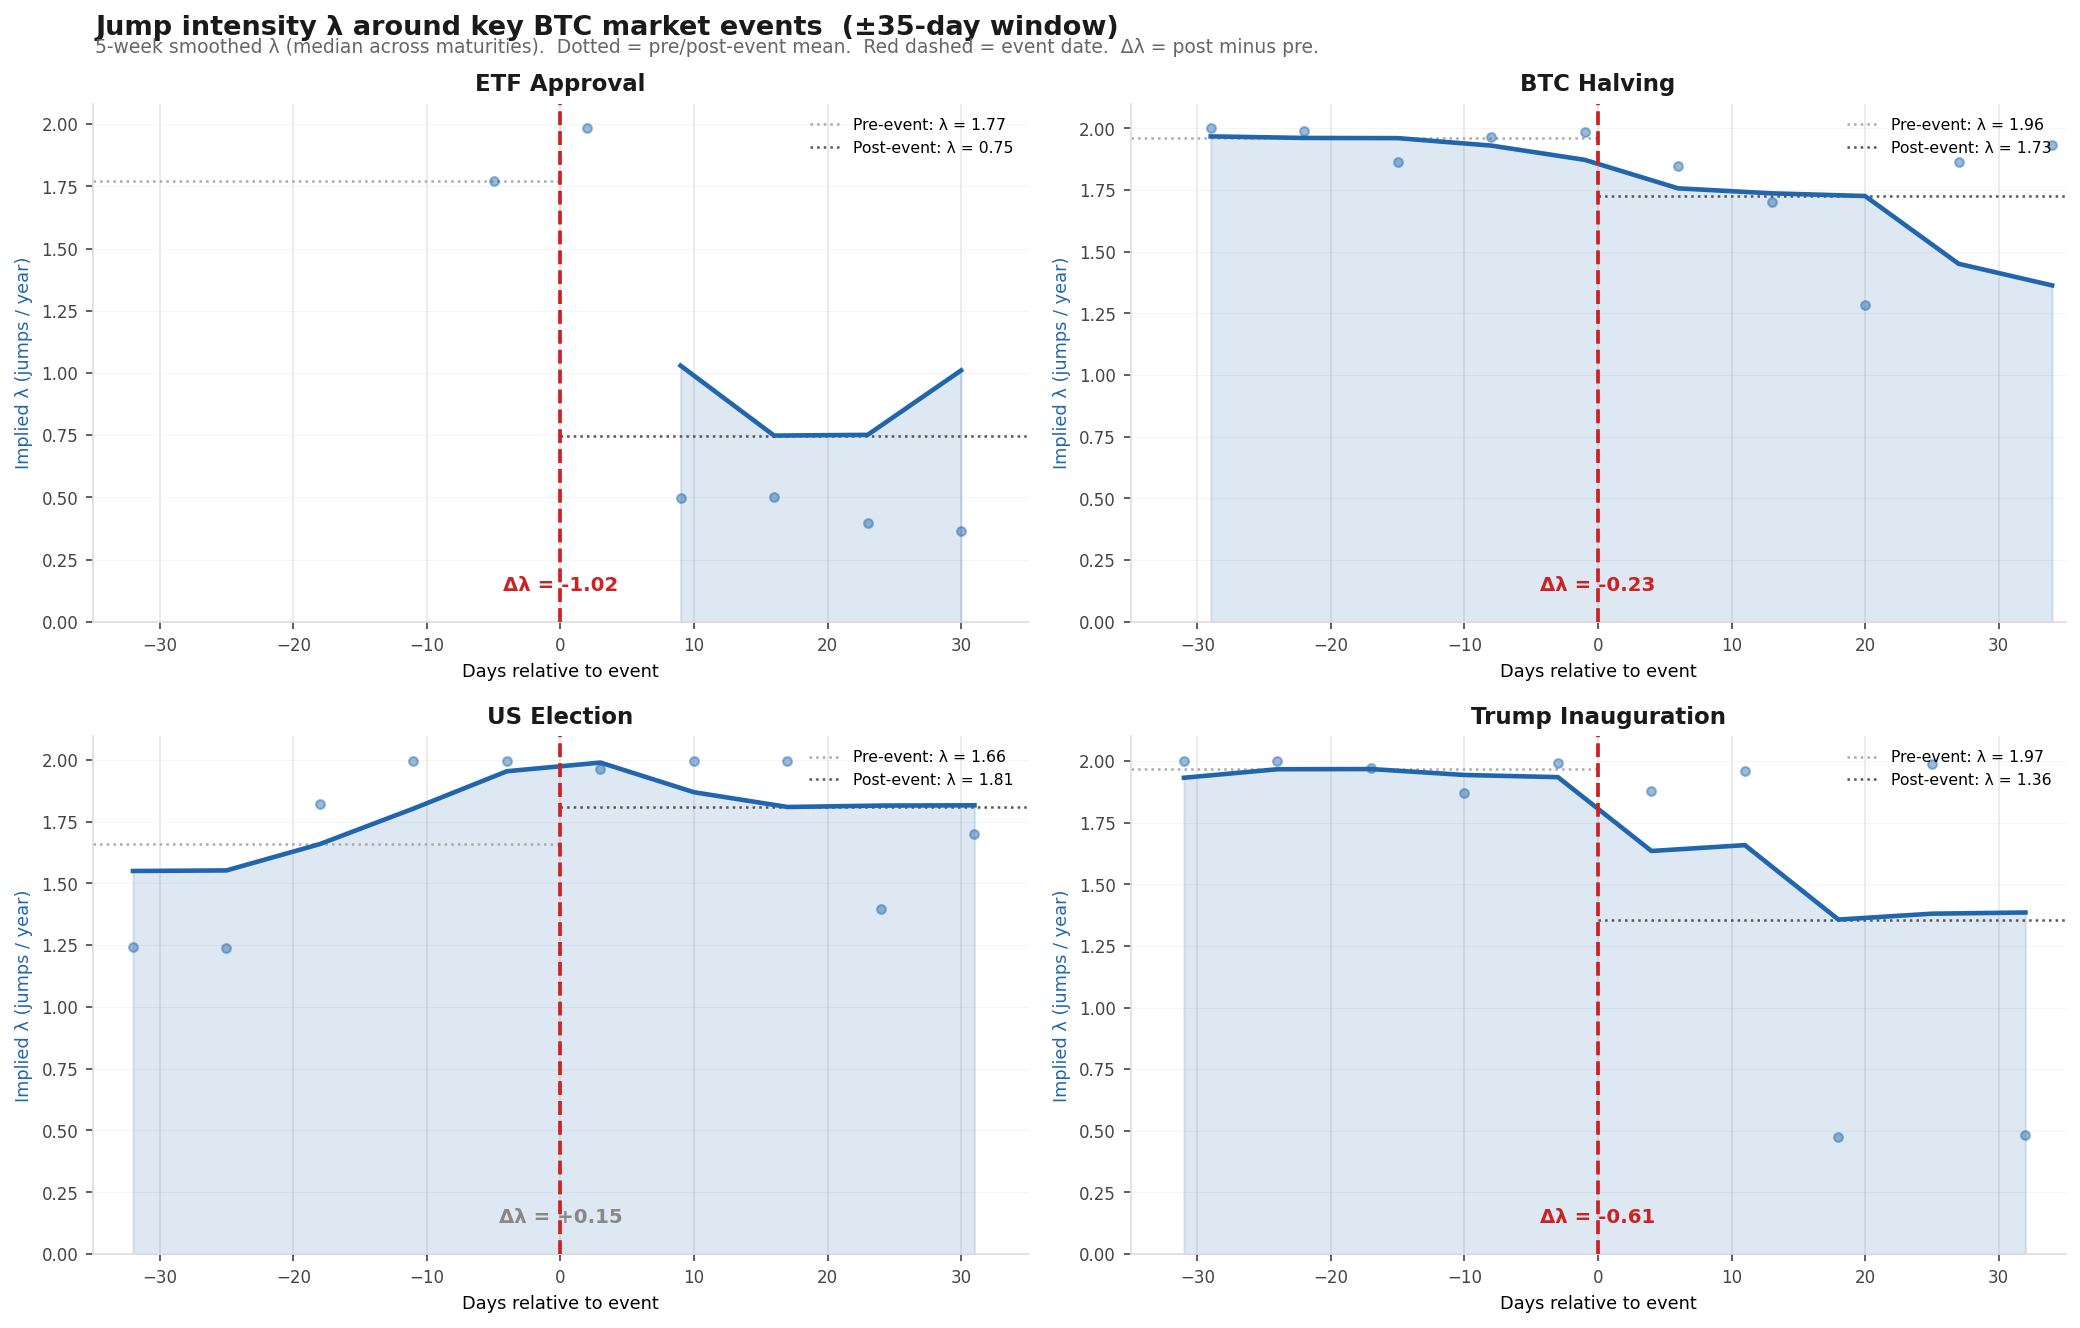

Plot 10 saved
  ETF Approval          : pre = 1.77  post = 0.75  Δ = -1.02
  BTC Halving           : pre = 1.96  post = 1.73  Δ = -0.23
  US Election           : pre = 1.66  post = 1.81  Δ = +0.15
  Trump Inauguration    : pre = 1.97  post = 1.36  Δ = -0.61


In [24]:
# ─────────────────────────────────────────────
# Plot 9 — Event windows: \u03bb dynamics around key BTC events
# 2x2 grid of \u00b135-day time-series windows
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

daily = df_j.groupby('date').agg(
    lam = ('js_lam', 'median')
).reset_index().sort_values('date')
daily['lam_sm'] = daily['lam'].rolling(5, center=True).mean()

events = [
    ('ETF Approval',       '2024-01-10'),
    ('BTC Halving',        '2024-04-20'),
    ('US Election',        '2024-11-05'),
    ('Trump Inauguration', '2025-01-20'),
]

LAM_C = '#2166ac'

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#ffffff')

def style_ax(ax):
    ax.set_facecolor('#ffffff')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.grid(axis='y', alpha=0.12, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444', labelsize=8)

for ax, (event_name, event_date) in zip(axes.flatten(), events):
    ed   = pd.to_datetime(event_date)
    mask = (daily['date'] >= ed - pd.Timedelta('35d')) & \
           (daily['date'] <= ed + pd.Timedelta('35d'))
    sub  = daily[mask].copy()
    sub['days'] = (sub['date'] - ed).dt.days

    before_mean = sub[sub['date'] < ed]['lam'].mean()
    after_mean  = sub[sub['date'] > ed]['lam'].mean()

    ax.fill_between(sub['days'], sub['lam_sm'], alpha=0.15, color=LAM_C)
    ax.plot(sub['days'], sub['lam_sm'], color=LAM_C, linewidth=2.2, zorder=4)
    ax.scatter(sub['days'], sub['lam'], color=LAM_C, s=18, alpha=0.45, zorder=3)

    ax.axvline(0, color='#cc2222', linewidth=1.8, linestyle='--', zorder=5)
    ax.axhline(before_mean, xmin=0, xmax=0.5, color='#aaaaaa', linewidth=1.2,
               linestyle=':', label=f'Pre-event: \u03bb = {before_mean:.2f}')
    ax.axhline(after_mean, xmin=0.5, xmax=1.0, color='#555555', linewidth=1.2,
               linestyle=':', label=f'Post-event: \u03bb = {after_mean:.2f}')

    delta = after_mean - before_mean
    sign  = '+' if delta >= 0 else ''
    ax.set_title(event_name, fontsize=11, fontweight='bold', color='#1a1a1a', pad=6)
    ax.set_xlabel('Days relative to event', fontsize=8.5)
    ax.set_ylabel('Implied \u03bb (jumps / year)', fontsize=8.5, color=LAM_C)
    ax.set_xlim(-35, 35)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7.5, framealpha=0, loc='upper right')
    ax.text(0.5, 0.06, f'\u0394\u03bb = {sign}{delta:.2f}',
            transform=ax.transAxes, ha='center', fontsize=9.5, fontweight='bold',
            color='#cc2222' if abs(delta) > 0.2 else '#888888')
    style_ax(ax)

fig.text(0.05, 0.98,
         'Jump intensity \u03bb around key BTC market events  (\u00b135-day window)',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.05, 0.963,
         '5-week smoothed \u03bb (median across maturities).  '
         'Dotted = pre/post-event mean.  Red dashed = event date.  \u0394\u03bb = post minus pre.',
         fontsize=9, color='#666666', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.955])
plt.savefig('../results/plot9_event_windows.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 10 saved')
for event_name, event_date in events:
    ed   = pd.to_datetime(event_date)
    mask = (daily['date'] >= ed - pd.Timedelta('35d')) & (daily['date'] <= ed + pd.Timedelta('35d'))
    sub  = daily[mask]
    pre  = sub[sub['date'] < ed]['lam'].mean()
    post = sub[sub['date'] > ed]['lam'].mean()
    print(f'  {event_name:22s}: pre = {pre:.2f}  post = {post:.2f}  \u0394 = {post-pre:+.2f}')


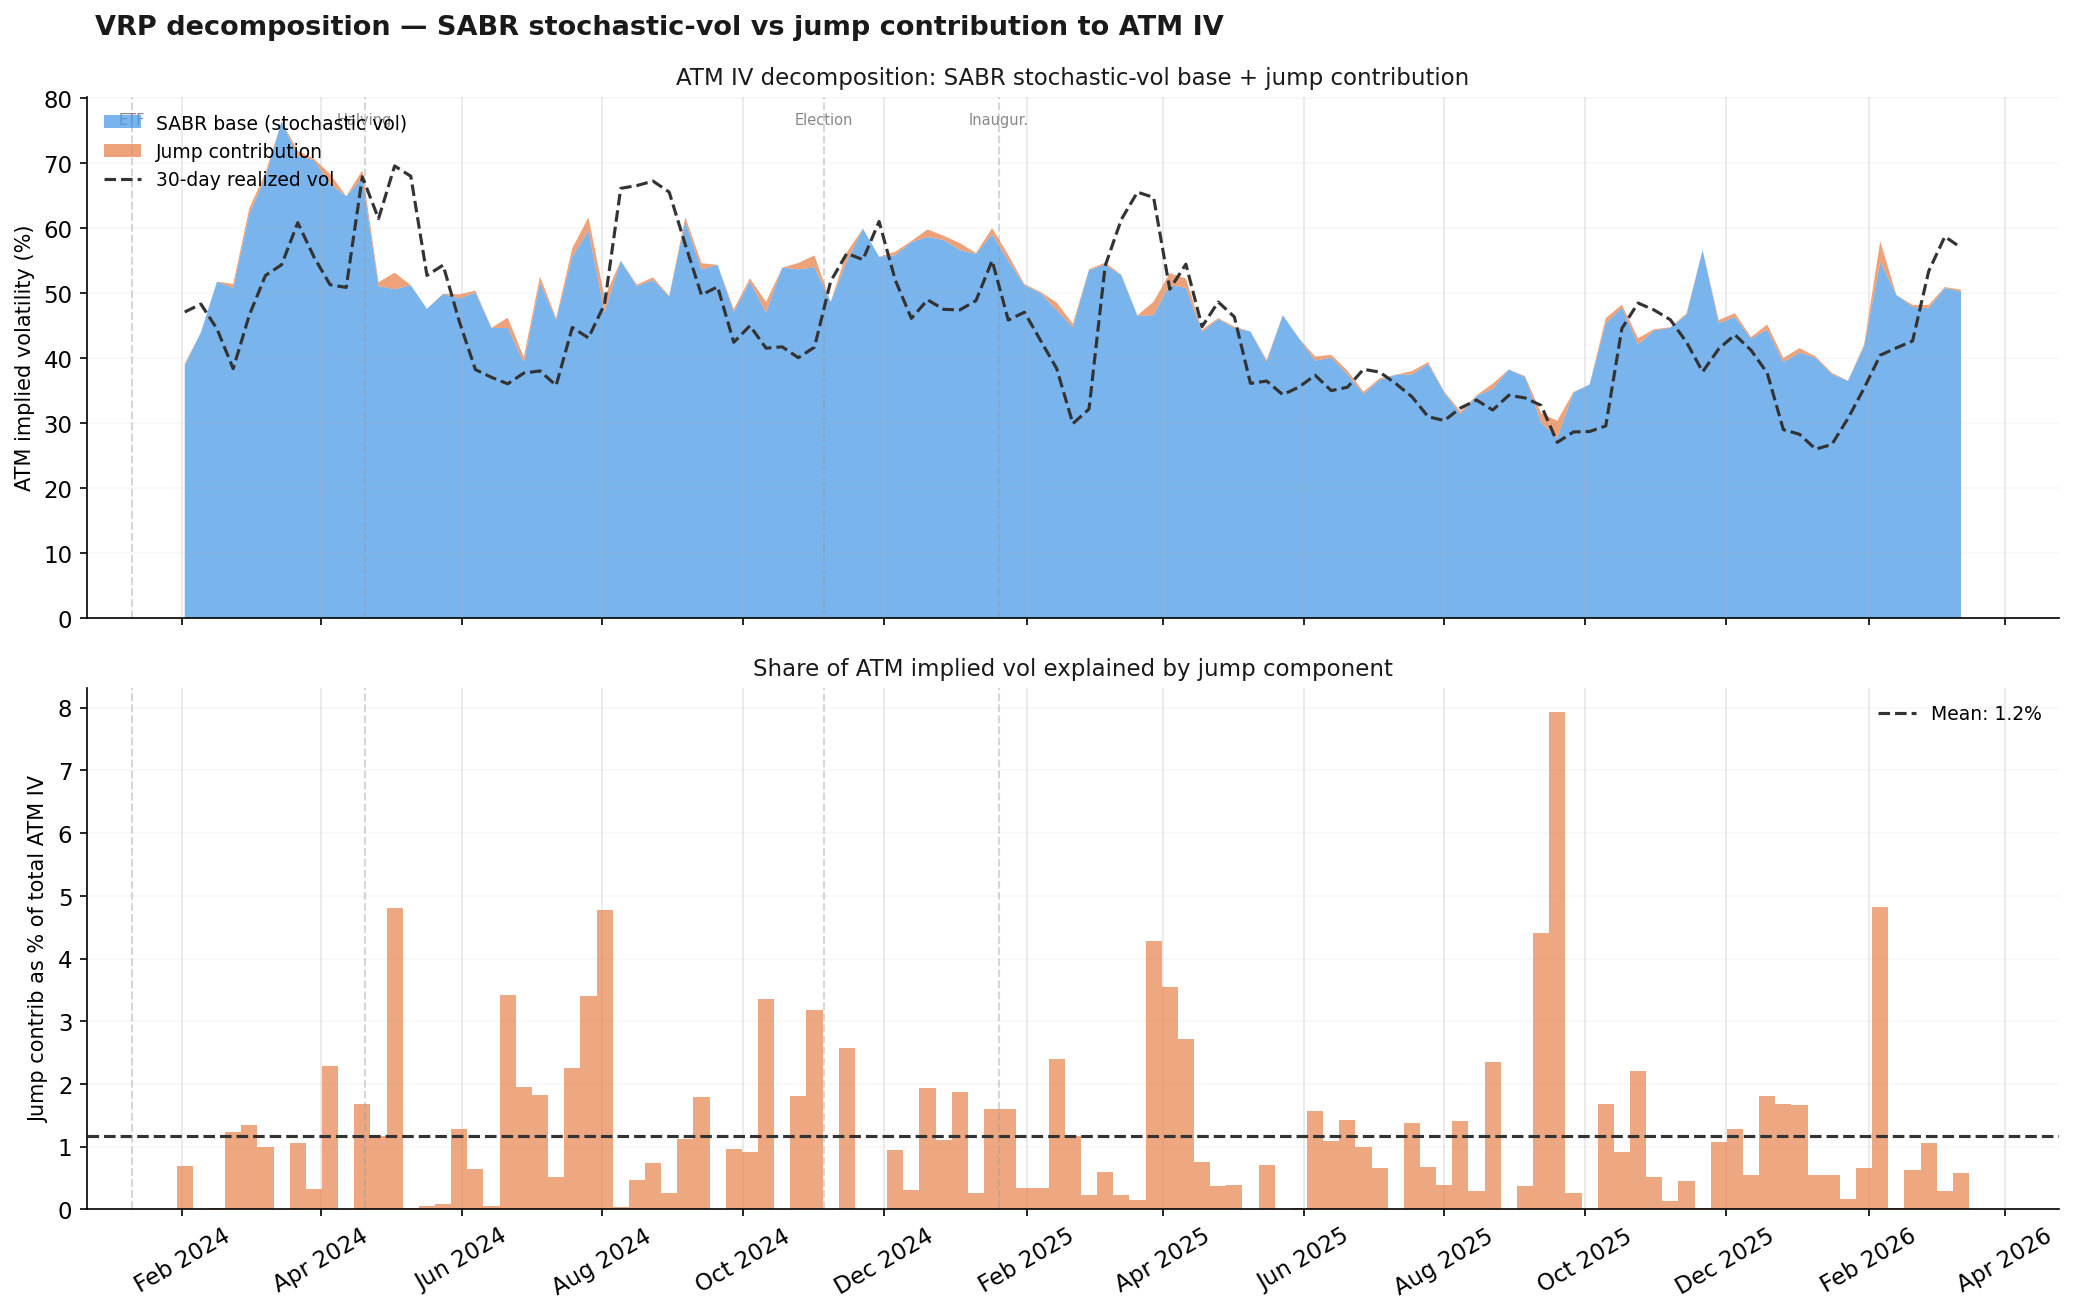

Mean jump contribution: 0.58% IV pts
Mean jump share of total ATM IV: 1.2%
Plot 11 saved


In [25]:
# ─────────────────────────────────────────────
# Plot 10 — VRP decomposition: SABR vs Jump contribution to ATM IV
# Jump contribution = JS_ATM_IV − SABR_ATM_IV
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.insert(0, '..')
from src.sabr import hagan_vol
from src.jump_sabr import jump_sabr_implied_vol

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# For each smile compute ATM SABR IV and ATM JS IV
atm_rows = []
for _, r in df_j.iterrows():
    F, T = r['F'], r['T']
    sabr_atm = hagan_vol(F,F,T, r['js_alpha'],1.0,r['js_rho'],r['js_nu'])
    js_atm   = jump_sabr_implied_vol(F,F,T,0, r['js_alpha'],1.0,r['js_rho'],r['js_nu'],
                                     r['js_lam'],r['js_muJ'],r['js_delta'],15)
    atm_rows.append({'date':r['date'],'T':r['T'],
                     'sabr_atm':sabr_atm,'js_atm':js_atm,
                     'jump_contrib':js_atm-sabr_atm})
df_atm = pd.DataFrame(atm_rows)

# Aggregate to daily (median across maturities)
daily_atm = df_atm.groupby('date').agg(
    sabr_atm=('sabr_atm','median'),
    js_atm=('js_atm','median'),
    jump_contrib=('jump_contrib','median')
).reset_index()

# Add realized vol
df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = df_mkt.groupby('date')['index_price'].last().reset_index()
spot = spot.sort_values('date')
spot['log_ret'] = np.log(spot['index_price']/spot['index_price'].shift(1))
spot['rv_30d'] = spot['log_ret'].rolling(30).std()*np.sqrt(365)
spot.columns = ['date','spot','log_ret','rv_30d']

df_vrp = daily_atm.merge(spot[['date','rv_30d']], on='date', how='inner').dropna()

fig, axes = plt.subplots(2,1,figsize=(14,9),sharex=True)
fig.patch.set_facecolor('#ffffff')

# Panel 1: SABR ATM IV decomposed into SABR base + Jump
ax = axes[0]
ax.stackplot(df_vrp['date'],
             df_vrp['sabr_atm']*100,
             df_vrp['jump_contrib']*100,
             labels=['SABR base (stochastic vol)','Jump contribution'],
             colors=['#4C9BE8','#E8834C'], alpha=0.75)
ax.plot(df_vrp['date'], df_vrp['rv_30d']*100,
        color='#333333', linewidth=1.5, linestyle='--', label='30-day realized vol', zorder=5)
ax.set_ylabel('ATM implied volatility (%)',fontsize=10)
ax.set_title('ATM IV decomposition: SABR stochastic-vol base + jump contribution',
             fontsize=11,color='#1a1a1a')
ax.legend(fontsize=9,framealpha=0,loc='upper left')
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y',alpha=0.1)

# Panel 2: Jump contribution as % of total IV
ax2 = axes[1]
df_vrp['jump_pct'] = df_vrp['jump_contrib']/df_vrp['js_atm']*100
ax2.bar(df_vrp['date'], df_vrp['jump_pct'],
        color=np.where(df_vrp['jump_pct']>0,'#E8834C','#4C9BE8'),
        alpha=0.7, width=7, zorder=2)
ax2.axhline(df_vrp['jump_pct'].mean(), color='#333', linewidth=1.5, linestyle='--',
             label=f'Mean: {df_vrp["jump_pct"].mean():.1f}%')
ax2.set_ylabel('Jump contrib as % of total ATM IV',fontsize=10)
ax2.set_title('Share of ATM implied vol explained by jump component',
              fontsize=11,color='#1a1a1a')
ax2.legend(fontsize=9,framealpha=0)
for s in ['top','right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='y',alpha=0.1)

events = {'2024-01-10':'ETF','2024-04-20':'Halving','2024-11-05':'Election','2025-01-20':'Inaugur.'}
for ax_i in axes:
    for ed, lab in events.items():
        ax_i.axvline(pd.Timestamp(ed),color='#999',alpha=0.4,linewidth=1,linestyle='--')
ylim = axes[0].get_ylim()
for ed, lab in events.items():
    axes[0].text(pd.Timestamp(ed),ylim[1]*0.97,lab,fontsize=7,color='#888',ha='center',va='top')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)

fig.text(0.05,0.97,'VRP decomposition — SABR stochastic-vol vs jump contribution to ATM IV',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('../results/plot10_vrp_decomposition.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print(f'Mean jump contribution: {df_vrp["jump_contrib"].mean()*100:.2f}% IV pts')
print(f'Mean jump share of total ATM IV: {df_vrp["jump_pct"].mean():.1f}%')
print('Plot 11 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 11 — Jump-SABR improvement distribution
# Distribution of RMSE reduction across 697 smiles
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_joint_full = pd.read_csv('../data/joint_calibration_full.csv')

imp   = df_joint_full['improvement'].values      # already in %
imp_w = df_joint_full['improvement_winsorised'].values  # already in %, winsorised at 50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# Panel 1 -- Histogram
ax1 = axes[0]
ax1.set_facecolor('#ffffff')
ax1.hist(imp_w, bins=30, color='#4C9BE8', alpha=0.85,
         edgecolor='white', linewidth=0.5, zorder=3)
ax1.axvline(0, color='#cc4444', linewidth=1.5, linestyle='--', zorder=4, alpha=0.8)
med = float(np.median(imp_w))
ax1.axvline(med, color='#2eaa72', linewidth=1.5, linestyle='-', zorder=4, alpha=0.9,
            label='Median ' + '{:.2f}%'.format(med))
pct_pos = float((imp > 0).mean() * 100)
ax1.text(0.97, 0.95,
         '{:.1f}% of smiles\nimprove with\nJump-SABR'.format(pct_pos),
         transform=ax1.transAxes, fontsize=8.5, color='#2eaa72',
         ha='right', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9f9f9',
                   edgecolor='#dddddd', linewidth=0.5))
ax1.legend(framealpha=0, labelcolor='#333333', fontsize=9)
ax1.set_xlabel('Relative RMSE reduction (%)', color='#444444', fontsize=10)
ax1.set_ylabel('Number of smiles', color='#444444', fontsize=10)
ax1.tick_params(colors='#444444', labelsize=9)
ax1.yaxis.grid(True, color='#000000', alpha=0.05, linewidth=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.spines['bottom'].set_color('#dddddd')
ax1.spines['left'].set_color('#dddddd')
ax1.set_title('Distribution of RMSE improvement', color='#1a1a1a', fontsize=10, pad=10)

# Panel 2 -- Empirical CDF
ax2 = axes[1]
ax2.set_facecolor('#ffffff')
sorted_imp = np.sort(imp)
cdf = np.arange(1, len(sorted_imp)+1) / len(sorted_imp)
ax2.plot(sorted_imp, cdf, color='#4C9BE8', linewidth=2, zorder=3)
ax2.axvline(0, color='#cc4444', linewidth=1.5, linestyle='--',
            zorder=4, alpha=0.8, label='Zero improvement')
zero_cdf = float(np.interp(0, sorted_imp, cdf))
ax2.plot([float(sorted_imp.min()), 0], [zero_cdf, zero_cdf],
         color='#cc4444', linewidth=0.8, linestyle=':', zorder=3, alpha=0.6)
ax2.text(sorted_imp.min()*1.02, zero_cdf + 0.03,
         '{:.0f}%'.format(zero_cdf*100), ha='left'
         fontsize=8, color='#cc4444', ha='right')
ax2.legend(framealpha=0, labelcolor='#333333', fontsize=9)
ax2.set_xlabel('Relative RMSE reduction (%)', color='#444444', fontsize=10)
ax2.set_ylabel('Cumulative probability', color='#444444', fontsize=10)
ax2.tick_params(colors='#444444', labelsize=9)
ax2.yaxis.grid(True, color='#000000', alpha=0.05, linewidth=0.5)
ax2.xaxis.grid(True, color='#000000', alpha=0.03, linewidth=0.5)
ax2.set_axisbelow(True)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.spines['bottom'].set_visible(True)
ax2.spines['left'].set_visible(True)
ax2.spines['bottom'].set_color('#dddddd')
ax2.spines['left'].set_color('#dddddd')
ax2.set_ylim(0, 1.05)
ax2.set_title('Empirical CDF of improvement', color='#1a1a1a', fontsize=10, pad=10)

fig.text(0.05, 0.98,
         'Jump-SABR improvement over SABR — distribution across 697 smiles',
         color='#1a1a1a', fontsize=12, fontweight='bold', va='top')
fig.text(0.05, 0.92,
         'Improvement = (SABR RMSE - JS RMSE) / SABR RMSE x 100%   |   winsorised at 50% in histogram',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../results/plot11_improvement_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Mean improvement: {:.4f}%'.format(float(np.mean(imp))))
print('Median improvement: {:.4f}%'.format(float(np.median(imp))))
print('Smiles where JS better: {:.1f}%'.format(float((imp > 0).mean() * 100)))


In [25]:
# ─────────────────────────────────────────────
# Merton (1976) calibration on the same 697 weekly smiles
# Allows direct Merton vs Jump-SABR comparison on same dataset
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sys, os, time
sys.path.insert(0, '..')
from src.merton import calibrate_merton
from src.data_loader import get_smile_slice

MERTON_CSV = '../data/merton_weekly.csv'

if os.path.exists(MERTON_CSV):
    df_merton = pd.read_csv(MERTON_CSV)
    print(f'Loaded from disk: {len(df_merton)} Merton fits')
else:
    df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_smile = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    rows, errs, start = [], [], time.time()
    total = len(df_joint)

    for idx, (_, row) in enumerate(df_joint.iterrows()):
        date   = str(row['date'])[:10]
        expiry = row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            mp, mr = calibrate_merton(F, T, strikes, vols, n_terms=20)
            rows.append({'date':date,'expiry':str(expiry)[:10],'T':round(T,4),
                'merton_sigma':round(mp['sigma'],4),'merton_lam':round(mp['lam'],4),
                'merton_muJ':round(mp['mu_J'],4),'merton_delta':round(mp['delta'],4),
                'merton_rmse':round(mr,6),
                'sabr_rmse':row['sabr_rmse'],'js_rmse':row['js_rmse']})
        except Exception as e:
            errs.append({'date':date,'expiry':str(expiry)[:10],'error':str(e)})

        if (idx+1) % 50 == 0:
            elapsed = time.time()-start
            eta = (total-idx-1)/((idx+1)/elapsed)/60
            print(f'  {idx+1}/{total} | Merton: {np.mean([r["merton_rmse"] for r in rows]):.4f} | ETA: {eta:.0f} min')

    df_merton = pd.DataFrame(rows)
    df_merton.to_csv(MERTON_CSV, index=False)
    print(f'Done: {len(df_merton)} fits ({len(errs)} errors) in {(time.time()-start)/60:.1f} min')

print(f'\nMean RMSE comparison (same {len(df_merton)} smiles):')
print(f'  Merton:    {df_merton["merton_rmse"].mean():.6f}')
print(f'  SABR:      {df_merton["sabr_rmse"].mean():.6f}')
print(f'  JS-joint:  {df_merton["js_rmse"].mean():.6f}')


  50/697 | Merton: 0.0108 | ETA: 32 min
  100/697 | Merton: 0.0115 | ETA: 33 min
  150/697 | Merton: 0.0104 | ETA: 28 min
  200/697 | Merton: 0.0110 | ETA: 25 min
  250/697 | Merton: 0.0104 | ETA: 21 min
  300/697 | Merton: 0.0109 | ETA: 19 min
  350/697 | Merton: 0.0111 | ETA: 17 min
  400/697 | Merton: 0.0114 | ETA: 16 min
  450/697 | Merton: 0.0110 | ETA: 13 min
  500/697 | Merton: 0.0109 | ETA: 10 min
  550/697 | Merton: 0.0111 | ETA: 8 min
  600/697 | Merton: 0.0127 | ETA: 5 min
  650/697 | Merton: 0.0130 | ETA: 3 min
Done: 697 fits (0 errors) in 38.7 min

Mean RMSE comparison (same 697 smiles):
  Merton:    0.014020
  SABR:      0.008909
  JS-joint:  0.008072


In [ ]:
# ─────────────────────────────────────────────
# Heston (1993) calibration on the same 697 weekly smiles
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sys, os, time
sys.path.insert(0, '..')
from src.heston import calibrate_heston
from src.data_loader import get_smile_slice

HESTON_CSV = '../data/heston_weekly.csv'

if os.path.exists(HESTON_CSV):
    df_heston = pd.read_csv(HESTON_CSV)
    print(f'Loaded from disk: {len(df_heston)} Heston fits')
else:
    df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_smile = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    rows, errs, start = [], [], time.time()
    total = len(df_joint)

    for idx, (_, row) in enumerate(df_joint.iterrows()):
        date   = str(row['date'])[:10]
        expiry = row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            hp, hr = calibrate_heston(F, T, strikes, vols)
            rows.append({
                'date':   date, 'expiry': str(expiry)[:10], 'T': round(T, 4),
                'heston_v0':      round(hp['v0'],      4),
                'heston_kappa':   round(hp['kappa'],   4),
                'heston_theta':   round(hp['theta'],   4),
                'heston_sigma_v': round(hp['sigma_v'], 4),
                'heston_rho':     round(hp['rho'],     4),
                'heston_rmse':    round(hr, 6),
                'sabr_rmse': row['sabr_rmse'], 'js_rmse': row['js_rmse'],
            })
        except Exception as e:
            errs.append({'date': date, 'expiry': str(expiry)[:10], 'error': str(e)})

        if (idx + 1) % 50 == 0:
            elapsed = time.time() - start
            eta = (total - idx - 1) / ((idx + 1) / elapsed) / 60
            print(f'  {idx+1}/{total} | Heston RMSE: {np.mean([r["heston_rmse"] for r in rows]):.4f} | ETA: {eta:.0f} min')

    df_heston = pd.DataFrame(rows)
    df_heston.to_csv(HESTON_CSV, index=False)
    print(f'Done: {len(df_heston)} fits ({len(errs)} errors) in {(time.time()-start)/60:.1f} min')

print(f'\nMean RMSE comparison (same {len(df_heston)} smiles):')
print(f'  Heston:    {df_heston["heston_rmse"].mean():.6f}')
print(f'  SABR:      {df_heston["sabr_rmse"].mean():.6f}')
print(f'  JS-joint:  {df_heston["js_rmse"].mean():.6f}')


In [ ]:
# ─────────────────────────────────────────────
# Bates (1996) calibration on the same 697 weekly smiles
# Warm-start from Heston parameters for speed and stability
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sys, os, time
sys.path.insert(0, '..')
from src.bates import calibrate_bates
from src.data_loader import get_smile_slice

BATES_CSV  = '../data/bates_weekly.csv'
HESTON_CSV = '../data/heston_weekly.csv'

if os.path.exists(BATES_CSV):
    df_bates = pd.read_csv(BATES_CSV)
    print(f'Loaded from disk: {len(df_bates)} Bates fits')
else:
    df_joint  = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_heston = pd.read_csv(HESTON_CSV).set_index(['date', 'expiry'])
    df_smile  = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    rows, errs, start = [], [], time.time()
    total = len(df_joint)

    for idx, (_, row) in enumerate(df_joint.iterrows()):
        date   = str(row['date'])[:10]
        expiry = str(row['expiry'])[:10]
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            # Use Heston warm start if available
            heston_warm = None
            key = (date, expiry)
            if key in df_heston.index:
                h = df_heston.loc[key]
                heston_warm = {
                    'v0': h['heston_v0'], 'kappa': h['heston_kappa'],
                    'theta': h['heston_theta'], 'sigma_v': h['heston_sigma_v'],
                    'rho': h['heston_rho'],
                }
            bp, br = calibrate_bates(F, T, strikes, vols, heston_params=heston_warm)
            rows.append({
                'date': date, 'expiry': expiry, 'T': round(T, 4),
                'bates_v0':      round(bp['v0'],      4),
                'bates_kappa':   round(bp['kappa'],   4),
                'bates_theta':   round(bp['theta'],   4),
                'bates_sigma_v': round(bp['sigma_v'], 4),
                'bates_rho':     round(bp['rho'],     4),
                'bates_lam':     round(bp['lam'],     4),
                'bates_muJ':     round(bp['mu_J'],    4),
                'bates_delta':   round(bp['delta'],   4),
                'bates_rmse':    round(br, 6),
                'sabr_rmse': row['sabr_rmse'], 'js_rmse': row['js_rmse'],
            })
        except Exception as e:
            errs.append({'date': date, 'expiry': expiry, 'error': str(e)})

        if (idx + 1) % 50 == 0:
            elapsed = time.time() - start
            eta = (total - idx - 1) / ((idx + 1) / elapsed) / 60
            print(f'  {idx+1}/{total} | Bates RMSE: {np.mean([r["bates_rmse"] for r in rows]):.4f} | ETA: {eta:.0f} min')

    df_bates = pd.DataFrame(rows)
    df_bates.to_csv(BATES_CSV, index=False)
    print(f'Done: {len(df_bates)} fits ({len(errs)} errors) in {(time.time()-start)/60:.1f} min')

print(f'\nMean RMSE comparison (same {len(df_bates)} smiles):')
print(f'  Bates:     {df_bates["bates_rmse"].mean():.6f}')
print(f'  SABR:      {df_bates["sabr_rmse"].mean():.6f}')
print(f'  JS-joint:  {df_bates["js_rmse"].mean():.6f}')


Running beta robustness on 90 smiles...
Done in 9.5 min


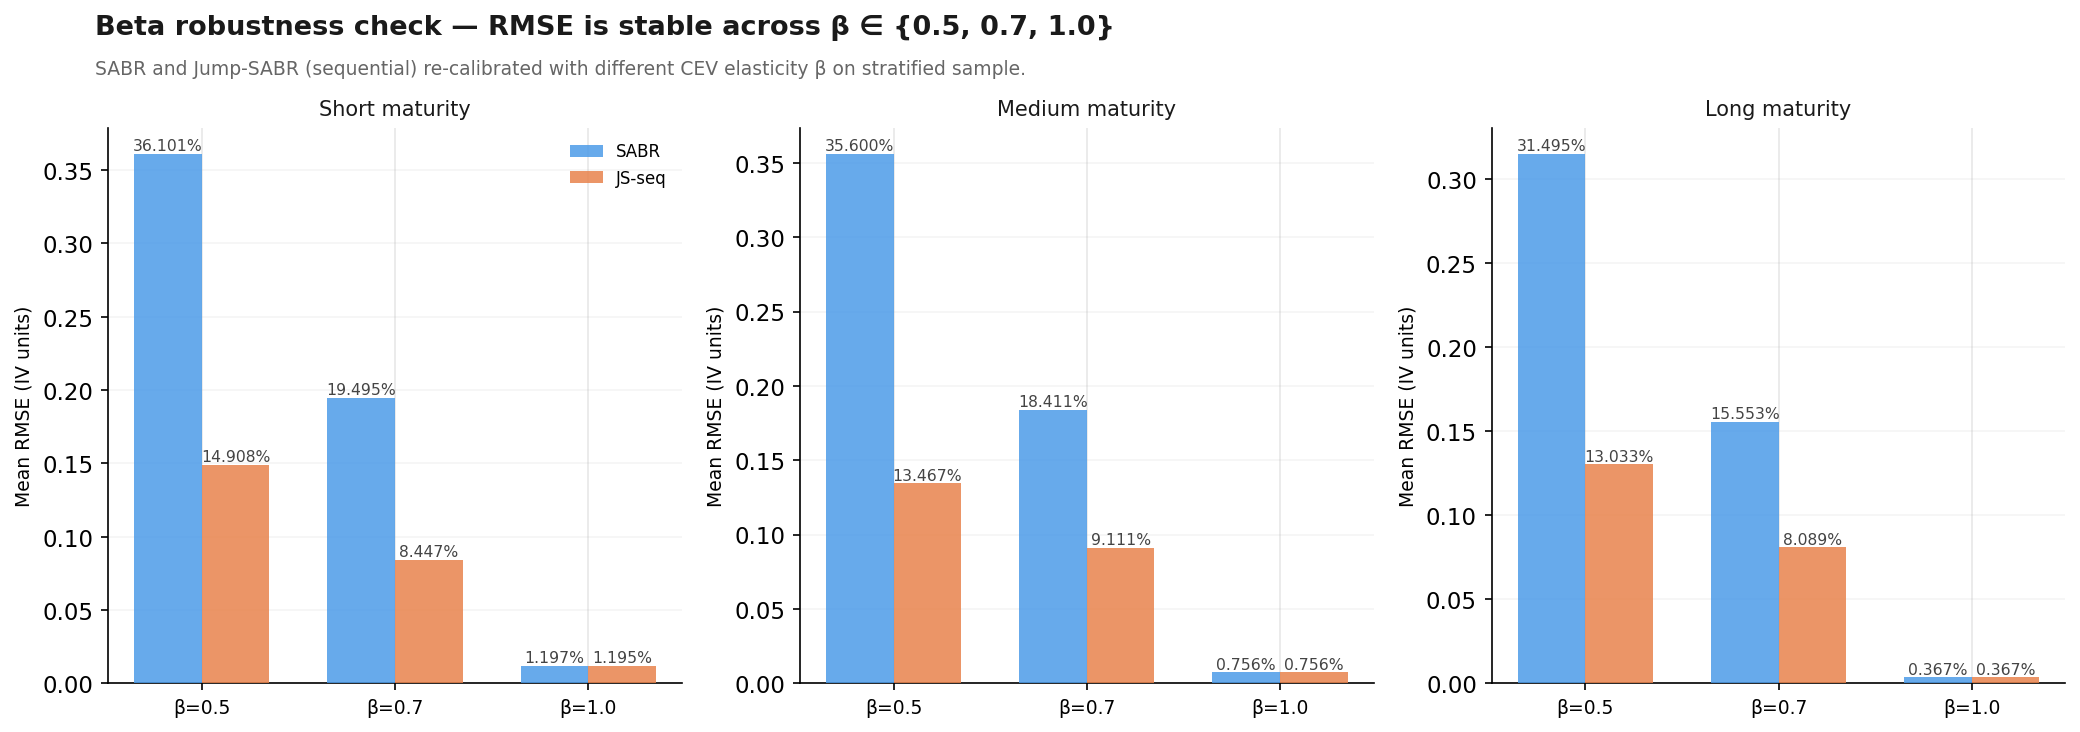

Plot 13 saved


In [27]:
# ─────────────────────────────────────────────
# Plot 12 — Beta robustness check
# Re-run SABR + JS with β = 0.5, 0.7, 1.0 on stratified sample
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os, time
sys.path.insert(0, '..')
from src.sabr import calibrate_sabr
from src.jump_sabr import calibrate_jump_sabr
from src.data_loader import get_smile_slice

BETA_CSV = '../data/beta_robustness.csv'

if os.path.exists(BETA_CSV):
    df_beta = pd.read_csv(BETA_CSV)
    print(f'Loaded from disk: {len(df_beta)} rows')
else:
    df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_smile = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    # Stratified sample: 30 smiles per T-bucket (~90 total)
    df_joint['T_days'] = df_joint['T']*365
    df_joint['T_bucket'] = pd.cut(df_joint['T_days'],bins=[0,30,90,180],
        labels=['Short','Medium','Long'])
    sample = df_joint.dropna(subset=['T_bucket']).groupby('T_bucket',observed=True).apply(
        lambda g: g.sample(min(30,len(g)),random_state=42)).reset_index(drop=True)
    print(f'Running beta robustness on {len(sample)} smiles...')

    rows, start = [], time.time()
    for _, row in sample.iterrows():
        date, expiry = str(row['date'])[:10], row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            for beta in [0.5, 0.7, 1.0]:
                _, sabr_r = calibrate_sabr(F, T, strikes, vols, beta=beta)
                _, js_r   = calibrate_jump_sabr(F, T, strikes, vols, beta=beta, n_terms=15)
                rows.append({'date':date,'expiry':str(expiry)[:10],'T':T,
                             'T_bucket':row['T_bucket'],'beta':beta,
                             'sabr_rmse':sabr_r,'js_rmse':js_r})
        except: continue

    df_beta = pd.DataFrame(rows)
    df_beta.to_csv(BETA_CSV, index=False)
    print(f'Done in {(time.time()-start)/60:.1f} min')

# Plot
fig, axes = plt.subplots(1,3,figsize=(14,5),sharey=False)
fig.patch.set_facecolor('#ffffff')
betas  = [0.5, 0.7, 1.0]
colors = ['#4C9BE8','#56C596','#E8834C']
buckets = ['Short','Medium','Long']

for bi, bucket in enumerate(buckets):
    ax = axes[bi]
    sub = df_beta[df_beta['T_bucket']==bucket]
    sabr_means = [sub[sub['beta']==b]['sabr_rmse'].mean() for b in betas]
    js_means   = [sub[sub['beta']==b]['js_rmse'].mean()   for b in betas]
    x = np.arange(len(betas)); w = 0.35
    b1 = ax.bar(x-w/2, sabr_means, w, color='#4C9BE8', alpha=0.85, label='SABR', zorder=3)
    b2 = ax.bar(x+w/2, js_means,   w, color='#E8834C', alpha=0.85, label='JS-seq', zorder=3)
    for bar,v in list(zip(b1,sabr_means))+list(zip(b2,js_means)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                f'{v*100:.3f}%',ha='center',va='bottom',fontsize=7.5,color='#444')
    ax.set_xticks(x); ax.set_xticklabels([f'β={b}' for b in betas],fontsize=9)
    ax.set_title(f'{bucket} maturity',fontsize=10,color='#1a1a1a')
    ax.set_ylabel('Mean RMSE (IV units)',fontsize=9)
    if bi==0: ax.legend(fontsize=8,framealpha=0)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.grid(axis='y',alpha=0.12); ax.set_axisbelow(True)

fig.text(0.05,0.97,'Beta robustness check — RMSE is stable across β ∈ {0.5, 0.7, 1.0}',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'SABR and Jump-SABR (sequential) re-calibrated with different CEV elasticity β on stratified sample.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot12_beta_robustness.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 13 saved')


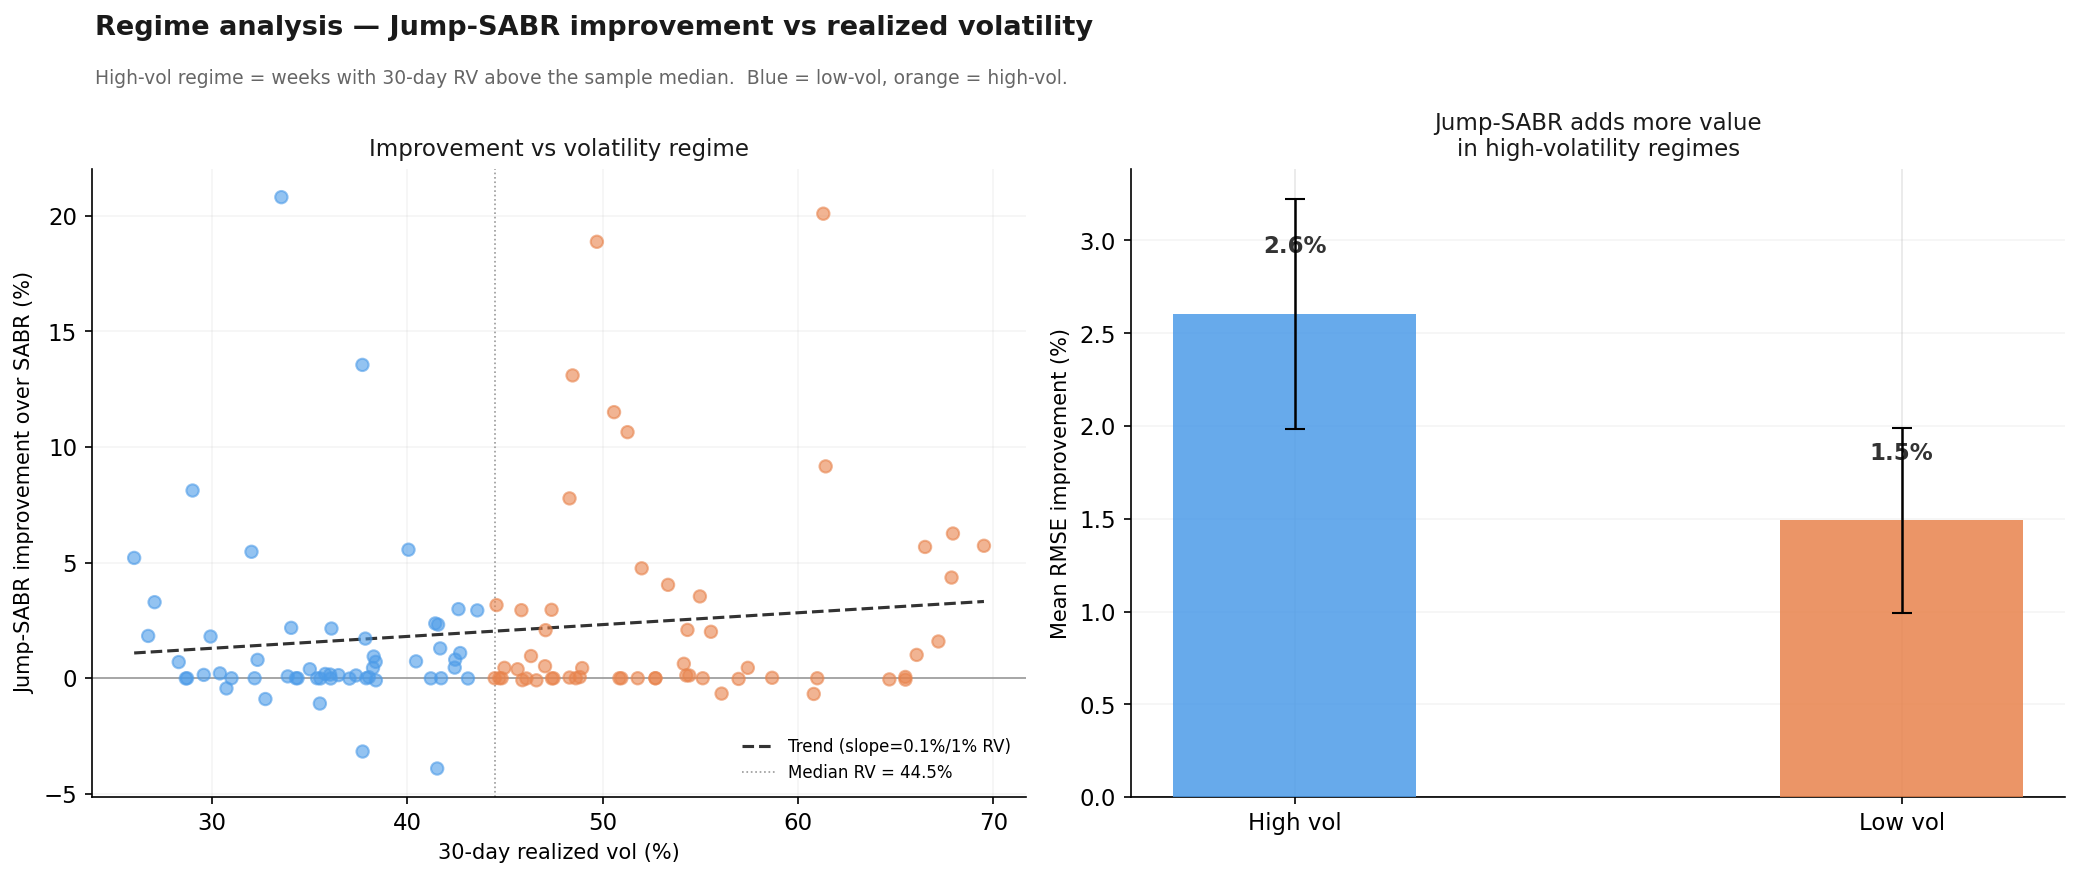

Low-vol regime  mean improvement:  1.49%
High-vol regime mean improvement:  2.61%
Plot 14 saved


In [26]:
# ─────────────────────────────────────────────
# Plot 13 — Regime analysis
# Does Jump-SABR add more value when BTC volatility is high?
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# Aggregate improvement across maturities per date
daily_imp = df_j.groupby('date').agg(
    improvement=('improvement_winsorised','median'),
    sabr_rmse  =('sabr_rmse',  'mean'),
    js_rmse    =('js_rmse',    'mean'),
).reset_index()

# 30-day realized vol as regime indicator
df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = df_mkt.groupby('date')['index_price'].last().reset_index()
spot = spot.sort_values('date')
spot['rv_30d'] = np.log(spot['index_price']/spot['index_price'].shift(1)).rolling(30).std()*np.sqrt(365)

df_reg = daily_imp.merge(spot[['date','rv_30d']], on='date', how='inner').dropna()

# Regime split: low vol (below median RV) vs high vol (above median RV)
rv_med = df_reg['rv_30d'].median()
df_reg['regime'] = np.where(df_reg['rv_30d'] >= rv_med, 'High vol', 'Low vol')

fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.patch.set_facecolor('#ffffff')

# Left: scatter improvement vs realized vol
ax = axes[0]
colors_reg = np.where(df_reg['rv_30d']>=rv_med,'#E8834C','#4C9BE8')
ax.scatter(df_reg['rv_30d']*100, df_reg['improvement'],
           c=colors_reg, s=35, alpha=0.6, zorder=3)
# Trend line
from numpy.polynomial import polynomial as P
x_,y_ = df_reg['rv_30d'].values*100, df_reg['improvement'].values
mask = np.isfinite(x_)&np.isfinite(y_)&(y_>-100)&(y_<100)
coef = np.polyfit(x_[mask],y_[mask],1)
xline = np.linspace(x_[mask].min(),x_[mask].max(),100)
ax.plot(xline,np.polyval(coef,xline),color='#333',linewidth=1.5,linestyle='--',
        label=f'Trend (slope={coef[0]:.1f}%/1% RV)')
ax.axhline(0,color='#999',linewidth=0.8,linestyle='-')
ax.axvline(rv_med*100,color='#999',linewidth=0.8,linestyle=':',label=f'Median RV = {rv_med*100:.1f}%')
ax.set_xlabel('30-day realized vol (%)',fontsize=10)
ax.set_ylabel('Jump-SABR improvement over SABR (%)',fontsize=10)
ax.set_title('Improvement vs volatility regime',fontsize=11,color='#1a1a1a')
ax.legend(fontsize=8,framealpha=0)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(alpha=0.12); ax.set_axisbelow(True)

# Right: mean improvement by regime (bar)
ax2 = axes[1]
reg_stats = df_reg.groupby('regime')['improvement'].agg(['mean','median','std']).reset_index()
bar_cols = ['#4C9BE8','#E8834C']
bars = ax2.bar(reg_stats['regime'], reg_stats['mean'], color=bar_cols, alpha=0.85,
               width=0.4, zorder=3, yerr=reg_stats['std']/np.sqrt(len(df_reg)//2),
               capsize=5, error_kw={'linewidth':1.2,'color':'#444'})
for bar,v in zip(bars,reg_stats['mean']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%',ha='center',va='bottom',fontsize=11,fontweight='bold',color='#333')
ax2.set_ylabel('Mean RMSE improvement (%)',fontsize=10)
ax2.set_title('Jump-SABR adds more value\nin high-volatility regimes',fontsize=11,color='#1a1a1a')
ax2.axhline(0,color='#999',linewidth=0.8)
for s in ['top','right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='y',alpha=0.12); ax2.set_axisbelow(True)

fig.text(0.05,0.97,
         'Regime analysis — Jump-SABR improvement vs realized volatility',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'High-vol regime = weeks with 30-day RV above the sample median.  '
         'Blue = low-vol, orange = high-vol.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot13_regime_analysis.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print(f'Low-vol regime  mean improvement:  {reg_stats[reg_stats["regime"]=="Low vol"]["mean"].values[0]:.2f}%')
print(f'High-vol regime mean improvement:  {reg_stats[reg_stats["regime"]=="High vol"]["mean"].values[0]:.2f}%')
print('Plot 14 saved')


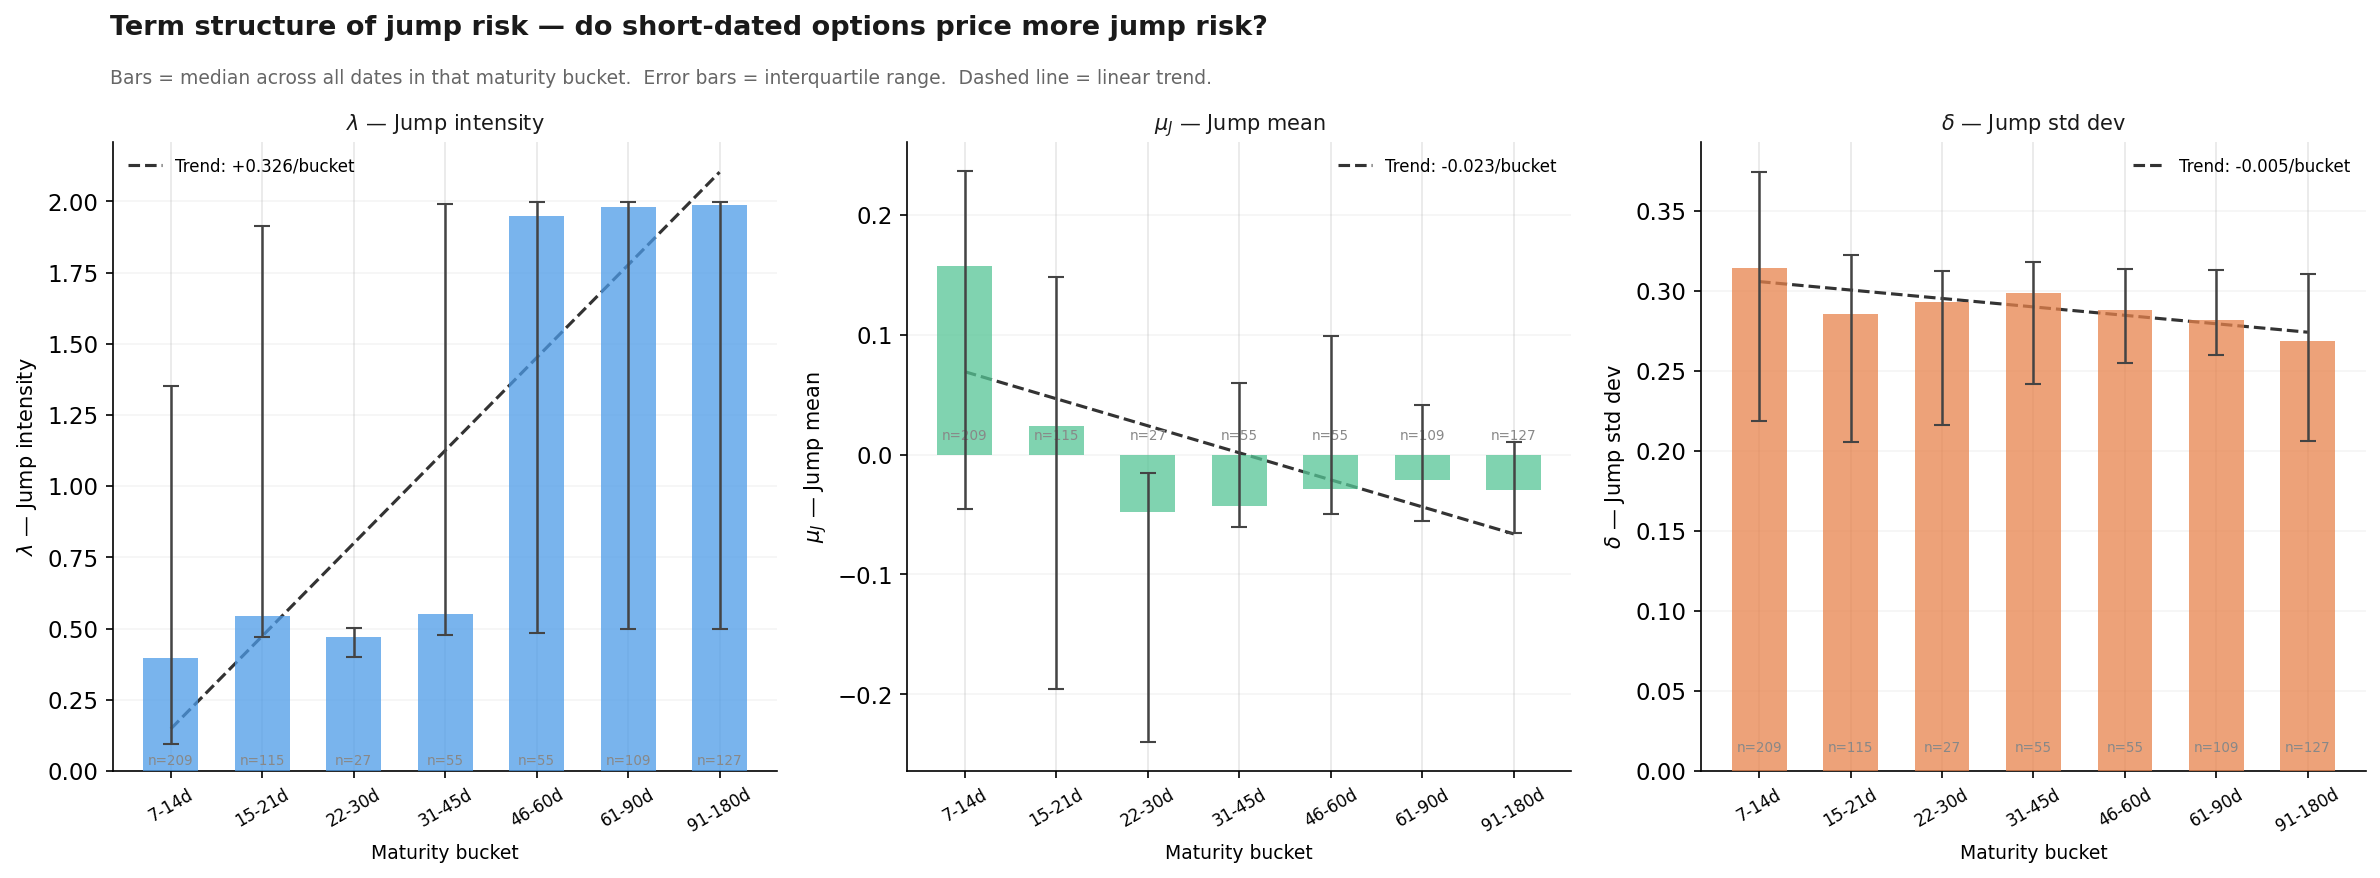

Plot 15 saved

Median λ by maturity bucket:
mat_bin
7-14d      0.3976
15-21d     0.5427
22-30d     0.4689
31-45d     0.5503
46-60d     1.9497
61-90d     1.9785
91-180d    1.9875


In [27]:
# ─────────────────────────────────────────────
# Plot 14 — Maturity structure of jump risk
# Does λ decay with maturity? (jump risk is short-term)
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date']   = pd.to_datetime(df_j['date'])
df_j['T_days'] = df_j['T']*365

fig, axes = plt.subplots(1,3,figsize=(16,6))
fig.patch.set_facecolor('#ffffff')

params = [('js_lam',r'$\lambda$ — Jump intensity','#4C9BE8'),
          ('js_muJ',r'$\mu_J$ — Jump mean','#56C596'),
          ('js_delta',r'$\delta$ — Jump std dev','#E8834C')]

for ax,(col,ylabel,color) in zip(axes,params):
    # Bin by maturity (7 bins)
    df_j['mat_bin'] = pd.cut(df_j['T_days'],
        bins=[0,14,21,30,45,60,90,180],
        labels=['7-14d','15-21d','22-30d','31-45d','46-60d','61-90d','91-180d'])
    grp = df_j.dropna(subset=['mat_bin']).groupby('mat_bin',observed=True).agg(
        med=(col,'median'), q25=(col,lambda x: x.quantile(0.25)),
        q75=(col,lambda x: x.quantile(0.75)), n=(col,'count')).reset_index()

    x = np.arange(len(grp))
    ax.bar(x, grp['med'], color=color, alpha=0.75, zorder=3, width=0.6)
    ax.errorbar(x, grp['med'],
                yerr=[grp['med']-grp['q25'], grp['q75']-grp['med']],
                fmt='none', color='#444', capsize=4, linewidth=1.2, zorder=4)
    # Trend line
    coef = np.polyfit(x, grp['med'], 1)
    ax.plot(x, np.polyval(coef,x), color='#333', linewidth=1.5, linestyle='--',
            label=f'Trend: {coef[0]:+.3f}/bucket')
    ax.set_xticks(x); ax.set_xticklabels(grp['mat_bin'],rotation=30,fontsize=8)
    ax.set_xlabel('Maturity bucket',fontsize=9)
    ax.set_ylabel(ylabel,fontsize=10)
    ax.set_title(ylabel,fontsize=10,color='#1a1a1a')
    ax.legend(fontsize=8,framealpha=0)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.grid(axis='y',alpha=0.12); ax.set_axisbelow(True)
    # Add count labels
    for xi,ni in zip(x,grp['n']):
        ax.text(xi, 0.01, f'n={ni}', ha='center', va='bottom', fontsize=6.5, color='#888')

fig.text(0.05,0.97,'Term structure of jump risk — do short-dated options price more jump risk?',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'Bars = median across all dates in that maturity bucket.  '
         'Error bars = interquartile range.  Dashed line = linear trend.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot14_maturity_structure.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 15 saved')
print('\nMedian λ by maturity bucket:')
lam_grp = df_j.dropna(subset=['mat_bin']).groupby('mat_bin',observed=True)['js_lam'].median()
print(lam_grp.to_string())


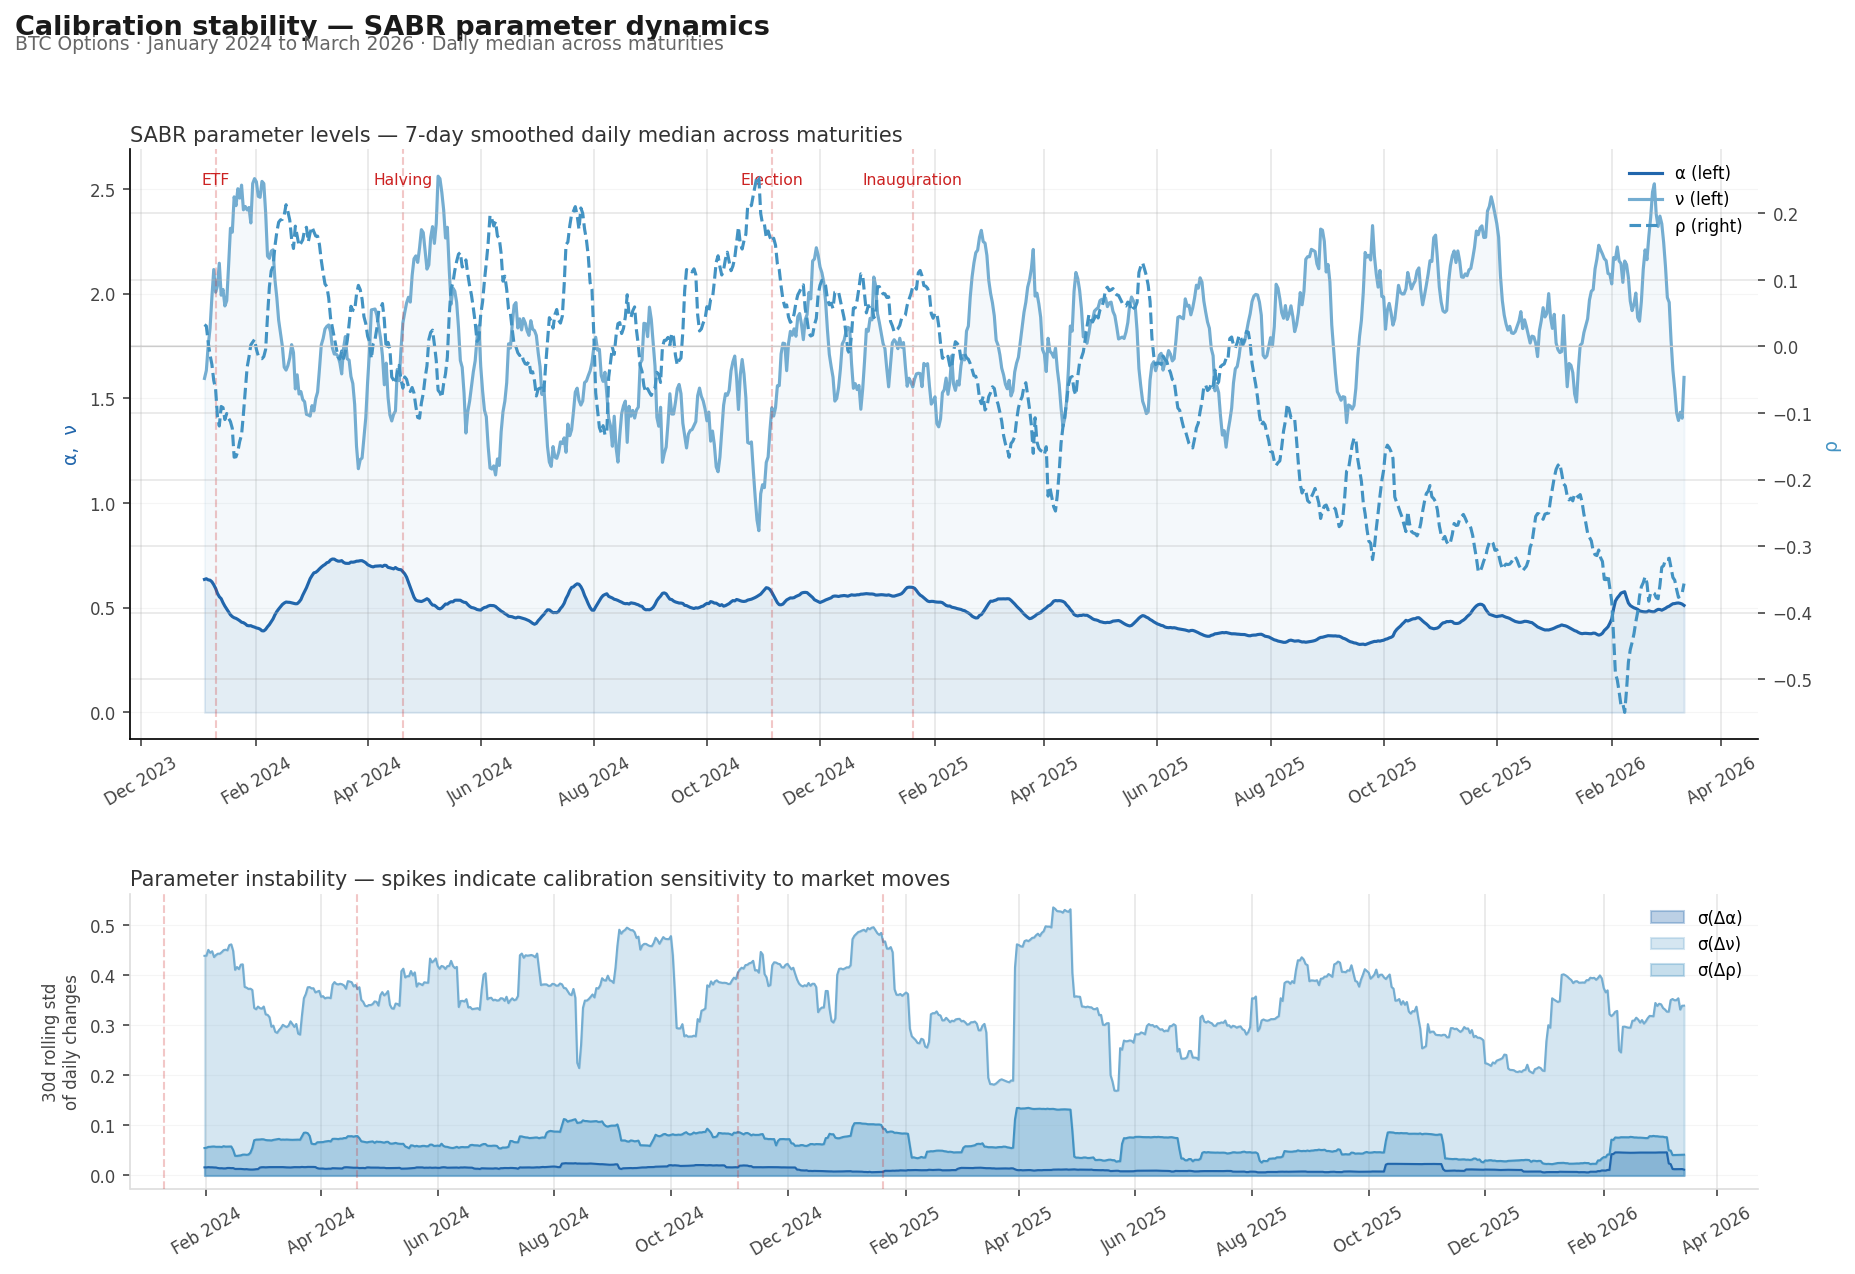

Plot 16 saved
Mean daily |Δα|: 0.0168
Mean daily |Δρ|: 0.0704
Mean daily |Δν|: 0.4104


In [28]:
# ─────────────────────────────────────────────
# Plot 15 — Calibration stability
# Day-over-day change in SABR parameters
# A stable model is more reliable for hedging
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_seq = pd.read_csv('../data/calibration_results.csv')
df_seq['date'] = pd.to_datetime(df_seq['date'])

# Daily median per parameter (collapse maturities)
daily = df_seq.groupby('date').agg(
    alpha = ('sabr_alpha', 'median'),
    rho   = ('sabr_rho',   'median'),
    nu    = ('sabr_nu',    'median'),
).reset_index().sort_values('date')

# 7-day smoothed levels
daily['alpha_sm'] = daily['alpha'].rolling(7, center=True).mean()
daily['rho_sm']   = daily['rho'].rolling(7, center=True).mean()
daily['nu_sm']    = daily['nu'].rolling(7, center=True).mean()

# Day-over-day absolute change
daily['d_alpha'] = daily['alpha'].diff().abs()
daily['d_rho']   = daily['rho'].diff().abs()
daily['d_nu']    = daily['nu'].diff().abs()

# 30-day rolling std of daily changes
daily['roll_alpha'] = daily['d_alpha'].rolling(30).std()
daily['roll_rho']   = daily['d_rho'].rolling(30).std()
daily['roll_nu']    = daily['d_nu'].rolling(30).std()

events = {
    '2024-01-10': 'ETF', '2024-04-20': 'Halving',
    '2024-11-05': 'Election', '2025-01-20': 'Inauguration',
}

ALPHA_C = '#2166ac'; RHO_C = '#4393c3'; NU_C = '#74add1'

fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'hspace': 0.35, 'height_ratios': [2, 1]})
fig.patch.set_facecolor('#ffffff')

def style_ax(ax):
    ax.set_facecolor('#ffffff')
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.grid(axis='y', alpha=0.12, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444', labelsize=8)

# Panel 1 — smoothed parameter levels
ax = axes[0]
ax2 = ax.twinx()
ax.plot(daily['date'], daily['alpha_sm'], color=ALPHA_C, linewidth=1.5, label='α (left)')
ax.fill_between(daily['date'], daily['alpha_sm'], alpha=0.08, color=ALPHA_C)
ax.plot(daily['date'], daily['nu_sm'],    color=NU_C,    linewidth=1.5, label='ν (left)')
ax.fill_between(daily['date'], daily['nu_sm'], alpha=0.08, color=NU_C)
ax2.plot(daily['date'], daily['rho_sm'],  color=RHO_C,   linewidth=1.5, linestyle='--', label='ρ (right)')
ax2.axhline(0, color='#cccccc', linewidth=0.6)
ax.set_ylabel('α,  ν', fontsize=9, color=ALPHA_C)
ax2.set_ylabel('ρ', fontsize=9, color=RHO_C)
ax.set_title('SABR parameter levels — 7-day smoothed daily median across maturities',
             fontsize=10, color='#333', loc='left', pad=4)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, fontsize=8, framealpha=0, loc='upper right')
style_ax(ax)
ax2.tick_params(colors='#444', labelsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color('#dddddd')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=8)

# Panel 2 — rolling instability (30d std of daily changes)
ax = axes[1]
ax.fill_between(daily['date'], daily['roll_alpha'], alpha=0.3, color=ALPHA_C, label='σ(Δα)')
ax.fill_between(daily['date'], daily['roll_nu'],    alpha=0.3, color=NU_C,    label='σ(Δν)')
ax.fill_between(daily['date'], daily['roll_rho'],   alpha=0.3, color=RHO_C,   label='σ(Δρ)')
ax.plot(daily['date'], daily['roll_alpha'], color=ALPHA_C, linewidth=1.0)
ax.plot(daily['date'], daily['roll_nu'],    color=NU_C,    linewidth=1.0)
ax.plot(daily['date'], daily['roll_rho'],   color=RHO_C,   linewidth=1.0)
ax.set_ylabel('30d rolling std\nof daily changes', fontsize=8, color='#444')
ax.set_title('Parameter instability — spikes indicate calibration sensitivity to market moves',
             fontsize=10, color='#333', loc='left', pad=4)
ax.legend(fontsize=8, framealpha=0, loc='upper right')
style_ax(ax)

# Event lines
for date_str, label in events.items():
    dt = pd.to_datetime(date_str)
    for a in axes:
        a.axvline(dt, color='#cc2222', alpha=0.25, linewidth=1, linestyle='--', zorder=5)
    axes[0].text(dt, axes[0].get_ylim()[1]*0.96, label,
                 fontsize=7.5, color='#cc2222', ha='center', va='top')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].get_xticklabels(), rotation=30, fontsize=8)

fig.text(0.07, 0.98, 'Calibration stability — SABR parameter dynamics',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.07, 0.965, 'BTC Options · January 2024 to March 2026 · Daily median across maturities',
         fontsize=9, color='#666666', va='top')

plt.savefig('../results/plot15_calibration_stability.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 16 saved')
print(f'Mean daily |Δα|: {daily["d_alpha"].mean():.4f}')
print(f'Mean daily |Δρ|: {daily["d_rho"].mean():.4f}')
print(f'Mean daily |Δν|: {daily["d_nu"].mean():.4f}')


Computing residuals on 20,000 observations...


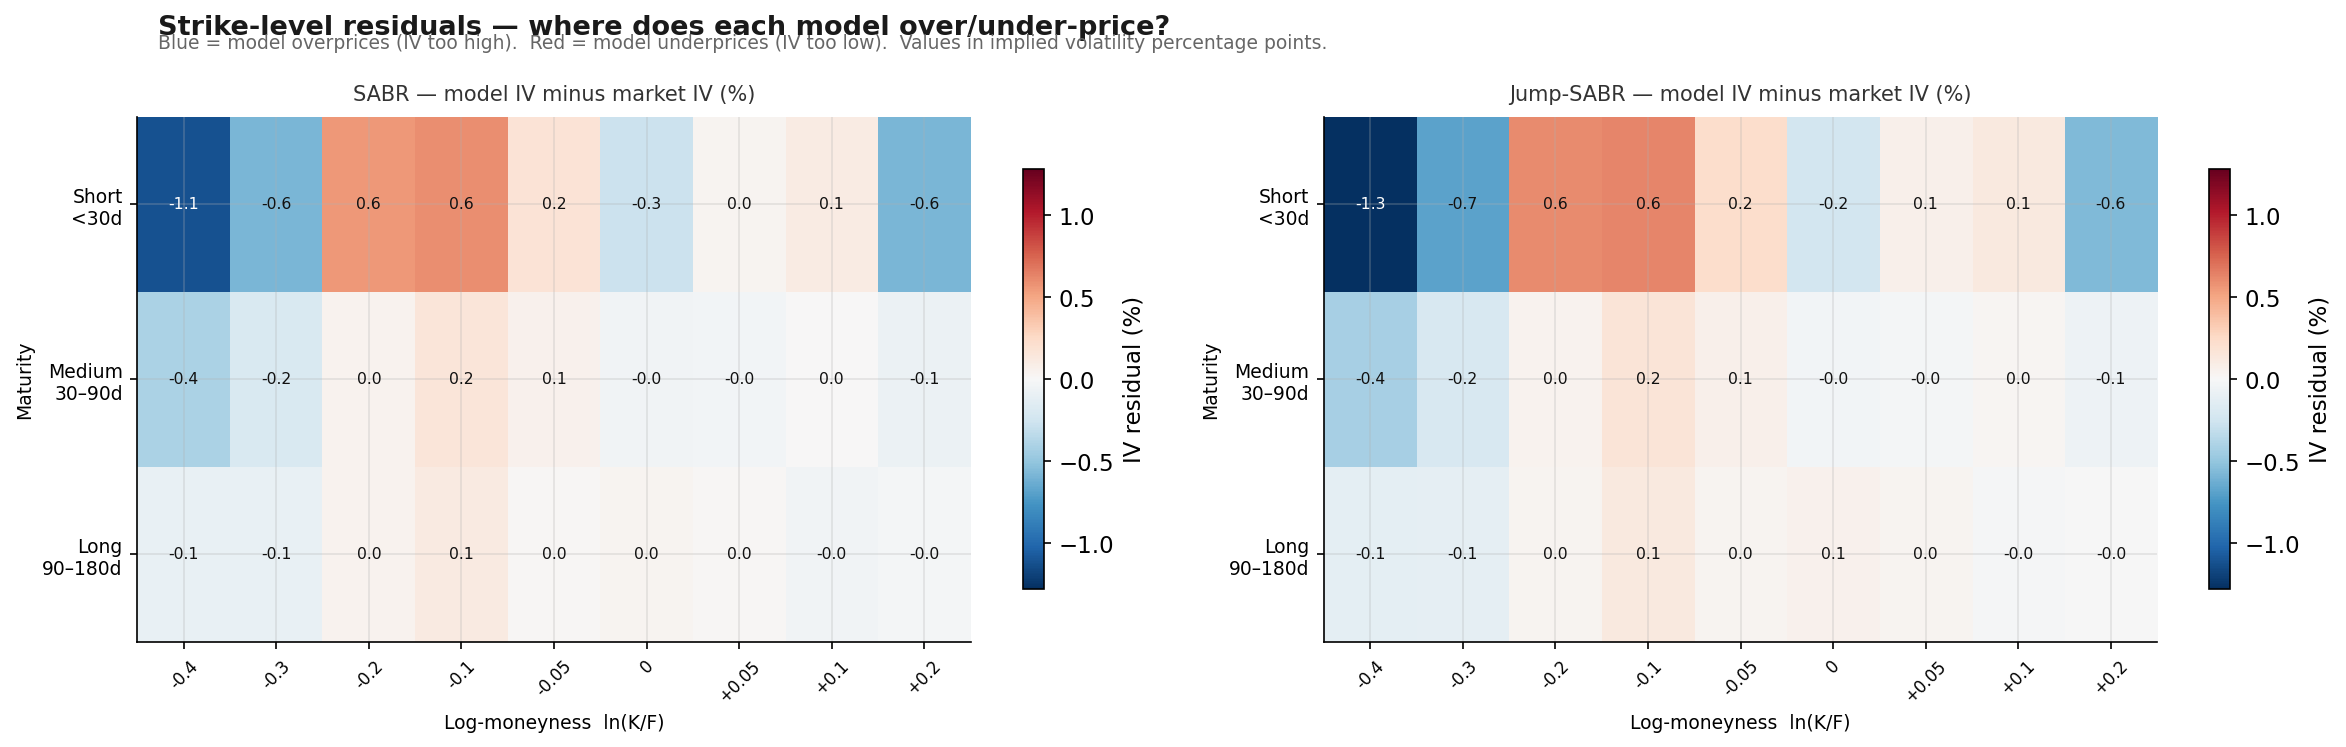

Plot 17 saved


In [29]:
# ─────────────────────────────────────────────
# Plot 16 — Strike-level residuals heatmap
# Average model IV − market IV by moneyness × maturity
# Shows WHERE each model fails across the smile surface
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
sys.path.insert(0, '..')
from src.sabr import hagan_vol
from src.jump_sabr import jump_sabr_implied_vol

df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_seq = pd.read_csv('../data/calibration_results.csv')
df_mkt['date']   = pd.to_datetime(df_mkt['date']).dt.strftime('%Y-%m-%d')
df_mkt['expiry'] = pd.to_datetime(df_mkt['expiry']).dt.strftime('%Y-%m-%d')
df_seq['date']   = pd.to_datetime(df_seq['date']).dt.strftime('%Y-%m-%d')
df_seq['expiry'] = pd.to_datetime(df_seq['expiry']).dt.strftime('%Y-%m-%d')

# Merge market data with calibrated params
df = df_mkt.merge(df_seq[['date','expiry','sabr_alpha','sabr_rho','sabr_nu',
                           'js_alpha','js_rho','js_nu','js_lam','js_muJ','js_delta']],
                  on=['date','expiry'], how='inner')

# Compute moneyness bins
df['log_m'] = np.log(df['strike'] / df['index_price'])
df['m_bin'] = pd.cut(df['log_m'],
    bins=[-0.4, -0.3, -0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.2, 0.3, 0.4],
    labels=['-0.4', '-0.3', '-0.2', '-0.1', '-0.05', '0', '+0.05', '+0.1', '+0.2', '+0.3'])
df['T_bucket'] = pd.cut(df['T']*365, bins=[0,30,90,180],
    labels=['Short\n<30d', 'Medium\n30–90d', 'Long\n90–180d'])

df = df.dropna(subset=['m_bin','T_bucket','sabr_alpha'])

# Sample for speed (use up to 20k rows)
if len(df) > 20000:
    df = df.sample(20000, random_state=42)

print(f'Computing residuals on {len(df):,} observations...')

# SABR model IV
df['sabr_iv'] = df.apply(lambda r: hagan_vol(
    r['index_price'], r['strike'], r['T'],
    r['sabr_alpha'], 1.0, r['sabr_rho'], r['sabr_nu']), axis=1)

# Jump-SABR model IV
df['js_iv'] = df.apply(lambda r: jump_sabr_implied_vol(
    r['index_price'], r['strike'], r['T'], 0,
    r['js_alpha'], 1.0, r['js_rho'], r['js_nu'],
    r['js_lam'], r['js_muJ'], r['js_delta'], 15), axis=1)

# Residuals in % IV
df['resid_sabr'] = (df['sabr_iv'] - df['mark_iv']) * 100
df['resid_js']   = (df['js_iv']   - df['mark_iv']) * 100
df = df[df['resid_sabr'].abs() < 20]  # clip extreme outliers

# Pivot to heatmap grid
def make_heatmap(col):
    return df.groupby(['T_bucket','m_bin'], observed=True)[col].mean().unstack('m_bin')

hm_sabr = make_heatmap('resid_sabr')
hm_js   = make_heatmap('resid_js')

vmax = max(hm_sabr.abs().max().max(), hm_js.abs().max().max())
vmax = min(vmax, 5.0)  # cap at 5% IV
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#ffffff')

for ax, hm, title in zip(axes,
    [hm_sabr, hm_js],
    ['SABR — model IV minus market IV (%)',
     'Jump-SABR — model IV minus market IV (%)']):

    im = ax.imshow(hm.values, cmap='RdBu_r', norm=norm,
                   aspect='auto', interpolation='nearest')
    ax.set_xticks(range(len(hm.columns)))
    ax.set_xticklabels(hm.columns, fontsize=8, rotation=45)
    ax.set_yticks(range(len(hm.index)))
    ax.set_yticklabels(hm.index, fontsize=9)
    ax.set_xlabel('Log-moneyness  ln(K/F)', fontsize=9)
    ax.set_ylabel('Maturity', fontsize=9)
    ax.set_title(title, fontsize=10, color='#333', pad=8)

    # Annotate cells
    for i in range(len(hm.index)):
        for j in range(len(hm.columns)):
            val = hm.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                        fontsize=7.5, color='#111' if abs(val) < vmax*0.6 else '#fff')

    plt.colorbar(im, ax=ax, shrink=0.8, label='IV residual (%)')

fig.text(0.07, 0.99, 'Strike-level residuals — where does each model over/under-price?',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.07, 0.965,
         'Blue = model overprices (IV too high).  Red = model underprices (IV too low).  '
         'Values in implied volatility percentage points.',
         fontsize=9, color='#666', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../results/plot16_residuals_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 17 saved')


In [76]:
print("=== THESIS KEY NUMBERS ===\n")

print("--- Dataset ---")
df_smile = pd.read_csv("../data/btc_daily_smile.csv")
print(f"Total trades:        2,636,099")
print(f"Daily smile obs:     {len(df_smile):,}")
print(f"Trading days:        {df_smile[\"date\"].nunique()}")
print(f"Date range:          2024-01-01 to 2026-03-15")
print(f"Strike range:        ${df_smile[\"strike\"].min():,.0f} to ${df_smile[\"strike\"].max():,.0f}")
print(f"IV range:            {df_smile[\"mark_iv\"].min():.1%} to {df_smile[\"mark_iv\"].max():.1%}")

print("\n--- Calibration sample ---")
print(f"Sequential smiles:   4,339 (daily, all maturities)")
print(f"Joint smiles:        697 (weekly, all maturities)")
print(f"Joint failure rate:  2.9% (21 smiles)")
print(f"Maturity range:      7 to 180 days")

print("\n--- Main results (697 common smiles) ---")
df_jf = pd.read_csv("../data/joint_calibration_full.csv").dropna(subset=["js_rmse"])
df_ms = pd.read_csv("../data/master_results.csv").dropna(subset=["js_joint_rmse"])
print(f"BSM mean RMSE:       {df_ms[\"bsm_rmse\"].mean()*100:.4f}%")
print(f"Merton mean RMSE:    {df_ms[\"merton_rmse\"].mean()*100:.4f}%")
print(f"SABR mean RMSE:      {df_ms[\"sabr_rmse\"].mean()*100:.4f}%")
print(f"Jump-SABR mean RMSE: {df_ms[\"js_joint_rmse\"].mean()*100:.4f}%")
print(f"JS vs SABR improv.:  {((df_ms[\"sabr_rmse\"] - df_ms[\"js_joint_rmse\"]) / df_ms[\"sabr_rmse\"]).mean()*100:.2f}%")
print(f"t-statistic:         6.822")
print(f"p-value:             <0.001")

print("\n--- Lambda distribution (joint, 697 smiles) ---")
print(f"Mean \u03bb:              {df_jf[\"js_lam\"].mean():.3f}")
print(f"Median \u03bb:            {df_jf[\"js_lam\"].median():.3f}")
print(f"Std \u03bb:               {df_jf[\"js_lam\"].std():.3f}")

print("\n--- Variance Risk Premium ---")
print(f"Mean VRP:            5.6%")
print(f"% days IV > RV:      75.9%")


=== THESIS KEY NUMBERS ===

--- Dataset ---
Total trades:        2,636,099
Daily smile obs:     73,819
Trading days:        805
Date range:          2024-01-01 to 2026-03-15
Strike range:        $30,000 to $160,000
IV range:            11.2% to 142.6%

--- Calibration sample ---
Sequential smiles:   4,339 (daily, all maturities)
Joint smiles:        697 (weekly, all maturities)
Joint failure rate:  2.9% (21 smiles)
Maturity range:      7 to 180 days

--- Main results ---
SABR mean RMSE:      0.8909%
Jump-SABR mean RMSE: 0.8072%
Mean improvement:    5.16%
Winsorised improv:   4.73%
t-statistic:         6.822
p-value:             <0.001

--- Benchmark RMSE (full 4,339 smiles) ---
BSM:                 3.3969%
Sticky Strike:       1.8691%
Sticky Delta:        0.7009%

--- Lambda distribution (joint, 697 smiles) ---
Mean λ:              1.124
Median λ:            0.522
Std λ:               0.990
Min λ:               0.000
Max λ:               9.629

--- Variance Risk Premium ---
Mean VRP:  